# NFL Record Projection Model

Goal: Use Pro Football Reference team-level data to build a rolling model that predicts each team's projected final record before each game of the 2025 NFL season.

In [1]:
import pandas as pd
import numpy as np
import requests
import time
from bs4 import BeautifulSoup
from io import StringIO

In [2]:
print("pandas version:", pd.__version__)

pandas version: 1.5.1


In [3]:
!pip install lxml

In [4]:
tables = pd.read_html("pfr_2024_games.html")
schedule_2024 = tables[0]
schedule_2024.head()

,Week,Day,Date,Time,Winner/tie,Unnamed: 5,Loser/tie,Date.1,Pts,Pts.1,YdsW,TOW,YdsL,TOL
0,1,Thu,2024-09-05,8:20PM,Kansas City Chiefs,NaN,Baltimore Ravens,boxscore,27,20,353,1,452,1
1,1,Fri,2024-09-06,8:15PM,Philadelphia Eagles,NaN,Green Bay Packers,boxscore,34,29,410,3,414,1
2,1,Sun,2024-09-08,1:00PM,Pittsburgh Steelers,@,Atlanta Falcons,boxscore,18,10,270,0,226,3
3,1,Sun,2024-09-08,1:00PM,Buffalo Bills,NaN,Arizona Cardinals,boxscore,34,28,352,1,270,1
4,1,Sun,2024-09-08,1:00PM,New Orleans Saints,NaN,Carolina Panthers,boxscore,47,10,379,1,193,3


In [5]:
schedule_2024.columns

Index(['Week', 'Day', 'Date', 'Time', 'Winner/tie', 'Unnamed: 5', 'Loser/tie',
       'Date.1', 'Pts', 'Pts.1', 'YdsW', 'TOW', 'YdsL', 'TOL'],
      dtype='object')

In [6]:
schedule_2024.shape

(303, 14)

In [7]:
schedule_2024["Week"].unique()

array(['1', 'Week', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
       '12', '13', '14', '15', '16', '17', '18', nan, 'WildCard',
       'Division', 'ConfChamp', 'SuperBowl'], dtype=object)

In [8]:
games_2024 = schedule_2024.copy()

games_2024["Week"] = pd.to_numeric(games_2024["Week"], errors="coerce")

games_2024 = games_2024[
    games_2024["Week"].between(1, 18)
].copy()

games_2024.shape

(272, 14)

In [9]:
games_2024 = games_2024.reset_index(drop=True)
games_2024.head()

,Week,Day,Date,Time,Winner/tie,Unnamed: 5,Loser/tie,Date.1,Pts,Pts.1,YdsW,TOW,YdsL,TOL
0,1.0,Thu,2024-09-05,8:20PM,Kansas City Chiefs,NaN,Baltimore Ravens,boxscore,27,20,353,1,452,1
1,1.0,Fri,2024-09-06,8:15PM,Philadelphia Eagles,NaN,Green Bay Packers,boxscore,34,29,410,3,414,1
2,1.0,Sun,2024-09-08,1:00PM,Pittsburgh Steelers,@,Atlanta Falcons,boxscore,18,10,270,0,226,3
3,1.0,Sun,2024-09-08,1:00PM,Buffalo Bills,NaN,Arizona Cardinals,boxscore,34,28,352,1,270,1
4,1.0,Sun,2024-09-08,1:00PM,New Orleans Saints,NaN,Carolina Panthers,boxscore,47,10,379,1,193,3


In [10]:
games_2024 = games_2024.rename(columns={
    "Week": "week",
    "Day": "day",
    "Date": "date",
    "Time": "time",
    "Winner/tie": "winner",
    "Unnamed: 5": "winner_location",
    "Loser/tie": "loser",
    "Date.1": "boxscore",
    "Pts": "winner_pts",
    "Pts.1": "loser_pts",
    "YdsW": "winner_yards",
    "TOW": "winner_turnovers",
    "YdsL": "loser_yards",
    "TOL": "loser_turnovers"
})

games_2024.head()

,week,day,date,time,winner,winner_location,loser,boxscore,winner_pts,loser_pts,winner_yards,winner_turnovers,loser_yards,loser_turnovers
0,1.0,Thu,2024-09-05,8:20PM,Kansas City Chiefs,NaN,Baltimore Ravens,boxscore,27,20,353,1,452,1
1,1.0,Fri,2024-09-06,8:15PM,Philadelphia Eagles,NaN,Green Bay Packers,boxscore,34,29,410,3,414,1
2,1.0,Sun,2024-09-08,1:00PM,Pittsburgh Steelers,@,Atlanta Falcons,boxscore,18,10,270,0,226,3
3,1.0,Sun,2024-09-08,1:00PM,Buffalo Bills,NaN,Arizona Cardinals,boxscore,34,28,352,1,270,1
4,1.0,Sun,2024-09-08,1:00PM,New Orleans Saints,NaN,Carolina Panthers,boxscore,47,10,379,1,193,3


In [11]:
games_2024.columns

Index(['week', 'day', 'date', 'time', 'winner', 'winner_location', 'loser',
       'boxscore', 'winner_pts', 'loser_pts', 'winner_yards',
       'winner_turnovers', 'loser_yards', 'loser_turnovers'],
      dtype='object')

In [12]:
games_2024["season"] = 2024

numeric_cols = [
    "week",
    "winner_pts",
    "loser_pts",
    "winner_yards",
    "winner_turnovers",
    "loser_yards",
    "loser_turnovers"
]

for col in numeric_cols:
    games_2024[col] = pd.to_numeric(games_2024[col], errors="coerce")

games_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week              272 non-null    float64
 1   day               272 non-null    object 
 2   date              272 non-null    object 
 3   time              272 non-null    object 
 4   winner            272 non-null    object 
 5   winner_location   127 non-null    object 
 6   loser             272 non-null    object 
 7   boxscore          272 non-null    object 
 8   winner_pts        272 non-null    int64  
 9   loser_pts         272 non-null    int64  
 10  winner_yards      272 non-null    int64  
 11  winner_turnovers  272 non-null    int64  
 12  loser_yards       272 non-null    int64  
 13  loser_turnovers   272 non-null    int64  
 14  season            272 non-null    int64  
dtypes: float64(1), int64(7), object(7)
memory usage: 32.0+ KB


### Fill missing winner location

In [13]:
games_2024["winner_location"] = games_2024["winner_location"].fillna("")

In [14]:
games_2024["winner_location"].value_counts(dropna=False)

     145
@    127
Name: winner_location, dtype: int64

### Home and away teams

In [15]:
games_2024["away_team"] = np.where(
    games_2024["winner_location"] == "@",
    games_2024["winner"],
    games_2024["loser"]
)

games_2024["home_team"] = np.where(
    games_2024["winner_location"] == "@",
    games_2024["loser"],
    games_2024["winner"]
)

### Home and away scores

In [16]:
games_2024["away_score"] = np.where(
    games_2024["winner_location"] == "@",
    games_2024["winner_pts"],
    games_2024["loser_pts"]
)

games_2024["home_score"] = np.where(
    games_2024["winner_location"] == "@",
    games_2024["loser_pts"],
    games_2024["winner_pts"]
)

### verify home / away logic

In [17]:
games_2024[[
    "week",
    "winner",
    "winner_location",
    "loser",
    "away_team",
    "home_team",
    "away_score",
    "home_score"
]].head(10)

,week,winner,winner_location,loser,away_team,home_team,away_score,home_score
0,1.0,Kansas City Chiefs,,Baltimore Ravens,Baltimore Ravens,Kansas City Chiefs,20,27
1,1.0,Philadelphia Eagles,,Green Bay Packers,Green Bay Packers,Philadelphia Eagles,29,34
2,1.0,Pittsburgh Steelers,@,Atlanta Falcons,Pittsburgh Steelers,Atlanta Falcons,18,10
3,1.0,Buffalo Bills,,Arizona Cardinals,Arizona Cardinals,Buffalo Bills,28,34
4,1.0,New Orleans Saints,,Carolina Panthers,Carolina Panthers,New Orleans Saints,10,47
5,1.0,Chicago Bears,,Tennessee Titans,Tennessee Titans,Chicago Bears,17,24
6,1.0,New England Patriots,@,Cincinnati Bengals,New England Patriots,Cincinnati Bengals,16,10
7,1.0,Houston Texans,@,Indianapolis Colts,Houston Texans,Indianapolis Colts,29,27
8,1.0,Miami Dolphins,,Jacksonville Jaguars,Jacksonville Jaguars,Miami Dolphins,17,20
9,1.0,Minnesota Vikings,@,New York Giants,Minnesota Vikings,New York Giants,28,6


### win / loss and margin columns

In [18]:
games_2024["home_win"] = (games_2024["home_score"] > games_2024["away_score"]).astype(int)
games_2024["away_win"] = (games_2024["away_score"] > games_2024["home_score"]).astype(int)

games_2024["home_margin"] = games_2024["home_score"] - games_2024["away_score"]
games_2024["away_margin"] = games_2024["away_score"] - games_2024["home_score"]

In [19]:
games_2024[[
    "week",
    "away_team",
    "home_team",
    "away_score",
    "home_score",
    "away_win",
    "home_win",
    "away_margin",
    "home_margin"
]].head(10)

,week,away_team,home_team,away_score,home_score,away_win,home_win,away_margin,home_margin
0,1.0,Baltimore Ravens,Kansas City Chiefs,20,27,0,1,-7,7
1,1.0,Green Bay Packers,Philadelphia Eagles,29,34,0,1,-5,5
2,1.0,Pittsburgh Steelers,Atlanta Falcons,18,10,1,0,8,-8
3,1.0,Arizona Cardinals,Buffalo Bills,28,34,0,1,-6,6
4,1.0,Carolina Panthers,New Orleans Saints,10,47,0,1,-37,37
5,1.0,Tennessee Titans,Chicago Bears,17,24,0,1,-7,7
6,1.0,New England Patriots,Cincinnati Bengals,16,10,1,0,6,-6
7,1.0,Houston Texans,Indianapolis Colts,29,27,1,0,2,-2
8,1.0,Jacksonville Jaguars,Miami Dolphins,17,20,0,1,-3,3
9,1.0,Minnesota Vikings,New York Giants,28,6,1,0,22,-22


In [20]:
clean_games_2024 = games_2024[[
    "season",
    "week",
    "day",
    "date",
    "time",
    "away_team",
    "home_team",
    "away_score",
    "home_score",
    "away_win",
    "home_win",
    "away_margin",
    "home_margin",
    "winner",
    "loser",
    "winner_location",
    "winner_yards",
    "winner_turnovers",
    "loser_yards",
    "loser_turnovers"
]].copy()

In [21]:
clean_games_2024.head()

,season,week,day,date,time,away_team,home_team,away_score,home_score,away_win,home_win,away_margin,home_margin,winner,loser,winner_location,winner_yards,winner_turnovers,loser_yards,loser_turnovers
0,2024,1.0,Thu,2024-09-05,8:20PM,Baltimore Ravens,Kansas City Chiefs,20,27,0,1,-7,7,Kansas City Chiefs,Baltimore Ravens,,353,1,452,1
1,2024,1.0,Fri,2024-09-06,8:15PM,Green Bay Packers,Philadelphia Eagles,29,34,0,1,-5,5,Philadelphia Eagles,Green Bay Packers,,410,3,414,1
2,2024,1.0,Sun,2024-09-08,1:00PM,Pittsburgh Steelers,Atlanta Falcons,18,10,1,0,8,-8,Pittsburgh Steelers,Atlanta Falcons,@,270,0,226,3
3,2024,1.0,Sun,2024-09-08,1:00PM,Arizona Cardinals,Buffalo Bills,28,34,0,1,-6,6,Buffalo Bills,Arizona Cardinals,,352,1,270,1
4,2024,1.0,Sun,2024-09-08,1:00PM,Carolina Panthers,New Orleans Saints,10,47,0,1,-37,37,New Orleans Saints,Carolina Panthers,,379,1,193,3


In [22]:
clean_games_2024.shape

(272, 20)

In [23]:
clean_games_2024.to_csv("clean_games_2024.csv", index=False)

In [24]:
test = pd.read_csv("clean_games_2024.csv")
test.head()

,season,week,day,date,time,away_team,home_team,away_score,home_score,away_win,home_win,away_margin,home_margin,winner,loser,winner_location,winner_yards,winner_turnovers,loser_yards,loser_turnovers
0,2024,1.0,Thu,2024-09-05,8:20PM,Baltimore Ravens,Kansas City Chiefs,20,27,0,1,-7,7,Kansas City Chiefs,Baltimore Ravens,NaN,353,1,452,1
1,2024,1.0,Fri,2024-09-06,8:15PM,Green Bay Packers,Philadelphia Eagles,29,34,0,1,-5,5,Philadelphia Eagles,Green Bay Packers,NaN,410,3,414,1
2,2024,1.0,Sun,2024-09-08,1:00PM,Pittsburgh Steelers,Atlanta Falcons,18,10,1,0,8,-8,Pittsburgh Steelers,Atlanta Falcons,@,270,0,226,3
3,2024,1.0,Sun,2024-09-08,1:00PM,Arizona Cardinals,Buffalo Bills,28,34,0,1,-6,6,Buffalo Bills,Arizona Cardinals,NaN,352,1,270,1
4,2024,1.0,Sun,2024-09-08,1:00PM,Carolina Panthers,New Orleans Saints,10,47,0,1,-37,37,New Orleans Saints,Carolina Panthers,NaN,379,1,193,3


In [25]:
print(clean_games_2024.shape)
print(clean_games_2024[["away_team", "home_team", "away_score", "home_score"]].head())
print(clean_games_2024[["away_score", "home_score"]].isna().sum())

(272, 20)
             away_team            home_team  away_score  home_score
0     Baltimore Ravens   Kansas City Chiefs          20          27
1    Green Bay Packers  Philadelphia Eagles          29          34
2  Pittsburgh Steelers      Atlanta Falcons          18          10
3    Arizona Cardinals        Buffalo Bills          28          34
4    Carolina Panthers   New Orleans Saints          10          47
away_score    0
home_score    0
dtype: int64


In [26]:
season_files = {
    2021: "pfr_2021_games.html",
    2022: "pfr_2022_games.html",
    2023: "pfr_2023_games.html",
    2024: "pfr_2024_games.html",
    2025: "pfr_2025_games.html"
}

In [27]:
def clean_pfr_schedule_html(file_path, season):
    """
    Reads one saved Pro Football Reference schedule HTML file
    and returns a clean regular-season game-level dataframe.
    
    Parameters
    ----------
    file_path : str
        Local path to saved PFR schedule HTML file.
        
    season : int
        NFL season year.
        
    Returns
    -------
    clean_games : pandas DataFrame
        Cleaned schedule/results dataframe for that regular season.
    """
    
    # Read all tables from saved HTML
    tables = pd.read_html(file_path)
    
    # PFR schedule table is usually the first table
    raw = tables[0].copy()
    
    # Convert Week to numeric.
    # This automatically turns 'WildCard', 'Division', 'SuperBowl',
    # repeated headers, and blanks into NaN.
    raw["Week"] = pd.to_numeric(raw["Week"], errors="coerce")
    
    # Keep only regular-season weeks 1 through 18
    games = raw[raw["Week"].between(1, 18)].copy()
    
    # Reset row index
    games = games.reset_index(drop=True)
    
    # Rename PFR columns
    games = games.rename(columns={
        "Week": "week",
        "Day": "day",
        "Date": "date",
        "Time": "time",
        "Winner/tie": "winner",
        "Unnamed: 5": "winner_location",
        "Loser/tie": "loser",
        "Date.1": "boxscore",
        "Pts": "winner_pts",
        "Pts.1": "loser_pts",
        "YdsW": "winner_yards",
        "TOW": "winner_turnovers",
        "YdsL": "loser_yards",
        "TOL": "loser_turnovers"
    })
    
    # Add season
    games["season"] = season
    
    # Convert numeric columns
    numeric_cols = [
        "week",
        "winner_pts",
        "loser_pts",
        "winner_yards",
        "winner_turnovers",
        "loser_yards",
        "loser_turnovers"
    ]
    
    for col in numeric_cols:
        games[col] = pd.to_numeric(games[col], errors="coerce")
    
    # Fill missing winner_location.
    # '@' means winner was away.
    # blank means winner was home.
    games["winner_location"] = games["winner_location"].fillna("")
    
    # Create away/home teams
    games["away_team"] = np.where(
        games["winner_location"] == "@",
        games["winner"],
        games["loser"]
    )
    
    games["home_team"] = np.where(
        games["winner_location"] == "@",
        games["loser"],
        games["winner"]
    )
    
    # Create away/home scores
    games["away_score"] = np.where(
        games["winner_location"] == "@",
        games["winner_pts"],
        games["loser_pts"]
    )
    
    games["home_score"] = np.where(
        games["winner_location"] == "@",
        games["loser_pts"],
        games["winner_pts"]
    )
    
    # Create win/loss and margin columns
    games["home_win"] = (games["home_score"] > games["away_score"]).astype(int)
    games["away_win"] = (games["away_score"] > games["home_score"]).astype(int)
    
    games["home_margin"] = games["home_score"] - games["away_score"]
    games["away_margin"] = games["away_score"] - games["home_score"]
    
    # Keep clean columns
    clean_games = games[[
        "season",
        "week",
        "day",
        "date",
        "time",
        "away_team",
        "home_team",
        "away_score",
        "home_score",
        "away_win",
        "home_win",
        "away_margin",
        "home_margin",
        "winner",
        "loser",
        "winner_location",
        "winner_yards",
        "winner_turnovers",
        "loser_yards",
        "loser_turnovers"
    ]].copy()
    
    return clean_games

In [28]:
test_2024 = clean_pfr_schedule_html("pfr_2024_games.html", 2024)

test_2024.head()

,season,week,day,date,time,away_team,home_team,away_score,home_score,away_win,home_win,away_margin,home_margin,winner,loser,winner_location,winner_yards,winner_turnovers,loser_yards,loser_turnovers
0,2024,1.0,Thu,2024-09-05,8:20PM,Baltimore Ravens,Kansas City Chiefs,20,27,0,1,-7,7,Kansas City Chiefs,Baltimore Ravens,,353,1,452,1
1,2024,1.0,Fri,2024-09-06,8:15PM,Green Bay Packers,Philadelphia Eagles,29,34,0,1,-5,5,Philadelphia Eagles,Green Bay Packers,,410,3,414,1
2,2024,1.0,Sun,2024-09-08,1:00PM,Pittsburgh Steelers,Atlanta Falcons,18,10,1,0,8,-8,Pittsburgh Steelers,Atlanta Falcons,@,270,0,226,3
3,2024,1.0,Sun,2024-09-08,1:00PM,Arizona Cardinals,Buffalo Bills,28,34,0,1,-6,6,Buffalo Bills,Arizona Cardinals,,352,1,270,1
4,2024,1.0,Sun,2024-09-08,1:00PM,Carolina Panthers,New Orleans Saints,10,47,0,1,-37,37,New Orleans Saints,Carolina Panthers,,379,1,193,3


In [29]:
test_2024.shape

(272, 20)

In [30]:
test_2024[["away_team", "home_team", "away_score", "home_score"]].head()

,away_team,home_team,away_score,home_score
0,Baltimore Ravens,Kansas City Chiefs,20,27
1,Green Bay Packers,Philadelphia Eagles,29,34
2,Pittsburgh Steelers,Atlanta Falcons,18,10
3,Arizona Cardinals,Buffalo Bills,28,34
4,Carolina Panthers,New Orleans Saints,10,47


In [31]:
all_clean_games = []

for season, file_path in season_files.items():
    print(f"Processing {season} from {file_path}...")
    
    season_games = clean_pfr_schedule_html(file_path, season)
    
    print(f"  Shape: {season_games.shape}")
    
    all_clean_games.append(season_games)

games_all = pd.concat(all_clean_games, ignore_index=True)

games_all.head()

Processing 2021 from pfr_2021_games.html...
  Shape: (272, 20)
Processing 2022 from pfr_2022_games.html...
  Shape: (271, 20)
Processing 2023 from pfr_2023_games.html...
  Shape: (272, 20)
Processing 2024 from pfr_2024_games.html...
  Shape: (272, 20)
Processing 2025 from pfr_2025_games.html...
  Shape: (272, 20)


,season,week,day,date,time,away_team,home_team,away_score,home_score,away_win,home_win,away_margin,home_margin,winner,loser,winner_location,winner_yards,winner_turnovers,loser_yards,loser_turnovers
0,2021,1.0,Thu,2021-09-09,8:20PM,Dallas Cowboys,Tampa Bay Buccaneers,29,31,0,1,-2,2,Tampa Bay Buccaneers,Dallas Cowboys,,431,4,451,1
1,2021,1.0,Sun,2021-09-12,1:00PM,Philadelphia Eagles,Atlanta Falcons,32,6,1,0,26,-26,Philadelphia Eagles,Atlanta Falcons,@,434,0,260,0
2,2021,1.0,Sun,2021-09-12,1:00PM,Pittsburgh Steelers,Buffalo Bills,23,16,1,0,7,-7,Pittsburgh Steelers,Buffalo Bills,@,252,0,371,1
3,2021,1.0,Sun,2021-09-12,1:00PM,New York Jets,Carolina Panthers,14,19,0,1,-5,5,Carolina Panthers,New York Jets,,381,1,252,1
4,2021,1.0,Sun,2021-09-12,1:00PM,Minnesota Vikings,Cincinnati Bengals,24,27,0,1,-3,3,Cincinnati Bengals,Minnesota Vikings,,366,0,403,1


In [32]:
games_all["season"].value_counts().sort_index()

2021    272
2022    271
2023    272
2024    272
2025    272
Name: season, dtype: int64

In [33]:
games_all.shape

(1359, 20)

In [34]:
games_all[["away_score", "home_score"]].isna().sum()

away_score    0
home_score    0
dtype: int64

In [35]:
games_all.groupby("season")["week"].agg(["min", "max", "nunique"])

,min,max,nunique
season,,,
2021,1.0,18.0,18
2022,1.0,18.0,18
2023,1.0,18.0,18
2024,1.0,18.0,18
2025,1.0,18.0,18


In [36]:
games_2022 = games_all[games_all["season"] == 2022].copy()

team_game_counts_2022 = pd.concat([
    games_2022["away_team"],
    games_2022["home_team"]
]).value_counts().sort_values()

team_game_counts_2022.head(10)

Buffalo Bills           16
Cincinnati Bengals      16
Cleveland Browns        17
San Francisco 49ers     17
Pittsburgh Steelers     17
Indianapolis Colts      17
Philadelphia Eagles     17
Jacksonville Jaguars    17
New England Patriots    17
Baltimore Ravens        17
dtype: int64

In [37]:
games_all[["away_win", "home_win"]].sum(axis=1).value_counts()

1    1355
0       4
dtype: int64

In [38]:
games_all[
    (games_all["away_win"] == 0) & 
    (games_all["home_win"] == 0)
][["season", "week", "away_team", "home_team", "away_score", "home_score"]]

,season,week,away_team,home_team,away_score,home_score
139,2021,10.0,Detroit Lions,Pittsburgh Steelers,16,16
277,2022,1.0,Indianapolis Colts,Houston Texans,20,20
457,2022,13.0,Washington Commanders,New York Giants,20,20
1148,2025,4.0,Green Bay Packers,Dallas Cowboys,40,40


In [39]:
games_all.to_csv("clean_games_2021_2025.csv", index=False)

In [40]:
test_all = pd.read_csv("clean_games_2021_2025.csv")
test_all.shape

(1359, 20)

In [41]:
games_all = pd.read_csv("clean_games_2021_2025.csv")

games_all.head()

,season,week,day,date,time,away_team,home_team,away_score,home_score,away_win,home_win,away_margin,home_margin,winner,loser,winner_location,winner_yards,winner_turnovers,loser_yards,loser_turnovers
0,2021,1.0,Thu,2021-09-09,8:20PM,Dallas Cowboys,Tampa Bay Buccaneers,29,31,0,1,-2,2,Tampa Bay Buccaneers,Dallas Cowboys,NaN,431,4,451,1
1,2021,1.0,Sun,2021-09-12,1:00PM,Philadelphia Eagles,Atlanta Falcons,32,6,1,0,26,-26,Philadelphia Eagles,Atlanta Falcons,@,434,0,260,0
2,2021,1.0,Sun,2021-09-12,1:00PM,Pittsburgh Steelers,Buffalo Bills,23,16,1,0,7,-7,Pittsburgh Steelers,Buffalo Bills,@,252,0,371,1
3,2021,1.0,Sun,2021-09-12,1:00PM,New York Jets,Carolina Panthers,14,19,0,1,-5,5,Carolina Panthers,New York Jets,NaN,381,1,252,1
4,2021,1.0,Sun,2021-09-12,1:00PM,Minnesota Vikings,Cincinnati Bengals,24,27,0,1,-3,3,Cincinnati Bengals,Minnesota Vikings,NaN,366,0,403,1


In [42]:
games_all.shape

(1359, 20)

In [43]:
games_all.columns

Index(['season', 'week', 'day', 'date', 'time', 'away_team', 'home_team',
       'away_score', 'home_score', 'away_win', 'home_win', 'away_margin',
       'home_margin', 'winner', 'loser', 'winner_location', 'winner_yards',
       'winner_turnovers', 'loser_yards', 'loser_turnovers'],
      dtype='object')

In [44]:
away_rows = games_all[[
    "season",
    "week",
    "day",
    "date",
    "time",
    "away_team",
    "home_team",
    "away_score",
    "home_score",
    "away_win",
    "away_margin"
]].copy()

In [45]:
away_rows = away_rows.rename(columns={
    "away_team": "team",
    "home_team": "opponent",
    "away_score": "team_score",
    "home_score": "opp_score",
    "away_win": "team_win",
    "away_margin": "team_margin"
})

In [46]:
away_rows["is_home"] = 0

In [47]:
away_rows.head()

,season,week,day,date,time,team,opponent,team_score,opp_score,team_win,team_margin,is_home
0,2021,1.0,Thu,2021-09-09,8:20PM,Dallas Cowboys,Tampa Bay Buccaneers,29,31,0,-2,0
1,2021,1.0,Sun,2021-09-12,1:00PM,Philadelphia Eagles,Atlanta Falcons,32,6,1,26,0
2,2021,1.0,Sun,2021-09-12,1:00PM,Pittsburgh Steelers,Buffalo Bills,23,16,1,7,0
3,2021,1.0,Sun,2021-09-12,1:00PM,New York Jets,Carolina Panthers,14,19,0,-5,0
4,2021,1.0,Sun,2021-09-12,1:00PM,Minnesota Vikings,Cincinnati Bengals,24,27,0,-3,0


In [48]:
home_rows = games_all[[
    "season",
    "week",
    "day",
    "date",
    "time",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "home_win",
    "home_margin"
]].copy()

In [49]:
home_rows = home_rows.rename(columns={
    "home_team": "team",
    "away_team": "opponent",
    "home_score": "team_score",
    "away_score": "opp_score",
    "home_win": "team_win",
    "home_margin": "team_margin"
})

In [50]:
home_rows["is_home"] = 1

In [51]:
home_rows.head()

,season,week,day,date,time,team,opponent,team_score,opp_score,team_win,team_margin,is_home
0,2021,1.0,Thu,2021-09-09,8:20PM,Tampa Bay Buccaneers,Dallas Cowboys,31,29,1,2,1
1,2021,1.0,Sun,2021-09-12,1:00PM,Atlanta Falcons,Philadelphia Eagles,6,32,0,-26,1
2,2021,1.0,Sun,2021-09-12,1:00PM,Buffalo Bills,Pittsburgh Steelers,16,23,0,-7,1
3,2021,1.0,Sun,2021-09-12,1:00PM,Carolina Panthers,New York Jets,19,14,1,5,1
4,2021,1.0,Sun,2021-09-12,1:00PM,Cincinnati Bengals,Minnesota Vikings,27,24,1,3,1


In [52]:
team_games = pd.concat([away_rows, home_rows], ignore_index=True)

In [53]:
team_games.head()

,season,week,day,date,time,team,opponent,team_score,opp_score,team_win,team_margin,is_home
0,2021,1.0,Thu,2021-09-09,8:20PM,Dallas Cowboys,Tampa Bay Buccaneers,29,31,0,-2,0
1,2021,1.0,Sun,2021-09-12,1:00PM,Philadelphia Eagles,Atlanta Falcons,32,6,1,26,0
2,2021,1.0,Sun,2021-09-12,1:00PM,Pittsburgh Steelers,Buffalo Bills,23,16,1,7,0
3,2021,1.0,Sun,2021-09-12,1:00PM,New York Jets,Carolina Panthers,14,19,0,-5,0
4,2021,1.0,Sun,2021-09-12,1:00PM,Minnesota Vikings,Cincinnati Bengals,24,27,0,-3,0


In [54]:
team_games.shape

(2718, 12)

In [55]:
team_games["team_tie"] = (team_games["team_score"] == team_games["opp_score"]).astype(int)

In [56]:
team_games["team_loss"] = (
    (team_games["team_win"] == 0) & 
    (team_games["team_tie"] == 0)
).astype(int)

In [57]:
team_games[team_games["team_tie"] == 1][[
    "season", "week", "team", "opponent", "team_score", "opp_score", "team_win", "team_loss", "team_tie"
]].head(10)

,season,week,team,opponent,team_score,opp_score,team_win,team_loss,team_tie
139,2021,10.0,Detroit Lions,Pittsburgh Steelers,16,16,0,0,1
277,2022,1.0,Indianapolis Colts,Houston Texans,20,20,0,0,1
457,2022,13.0,Washington Commanders,New York Giants,20,20,0,0,1
1148,2025,4.0,Green Bay Packers,Dallas Cowboys,40,40,0,0,1
1498,2021,10.0,Pittsburgh Steelers,Detroit Lions,16,16,0,0,1
1636,2022,1.0,Houston Texans,Indianapolis Colts,20,20,0,0,1
1816,2022,13.0,New York Giants,Washington Commanders,20,20,0,0,1
2507,2025,4.0,Dallas Cowboys,Green Bay Packers,40,40,0,0,1


In [58]:
team_games["team_tie"].sum()

8

In [59]:
team_games["points_for"] = team_games["team_score"]
team_games["points_against"] = team_games["opp_score"]
point_diff = team_games["points_for"] - team_games["points_against"]
team_games["point_diff"] = point_diff

In [60]:
team_games[[
    "team_score",
    "opp_score",
    "team_margin",
    "point_diff"
]].head()

,team_score,opp_score,team_margin,point_diff
0,29,31,-2,-2
1,32,6,26,26
2,23,16,7,7
3,14,19,-5,-5
4,24,27,-3,-3


In [61]:
(team_games["team_margin"] == team_games["point_diff"]).value_counts()

True    2718
dtype: int64

In [62]:
team_games = team_games.sort_values(
    by=["season", "week", "date", "time", "team"]
).reset_index(drop=True)

In [63]:
team_games.head(10)

,season,week,day,date,time,team,opponent,team_score,opp_score,team_win,team_margin,is_home,team_tie,team_loss,points_for,points_against,point_diff
0,2021,1.0,Thu,2021-09-09,8:20PM,Dallas Cowboys,Tampa Bay Buccaneers,29,31,0,-2,0,0,1,29,31,-2
1,2021,1.0,Thu,2021-09-09,8:20PM,Tampa Bay Buccaneers,Dallas Cowboys,31,29,1,2,1,0,0,31,29,2
2,2021,1.0,Sun,2021-09-12,1:00PM,Arizona Cardinals,Tennessee Titans,38,13,1,25,0,0,0,38,13,25
3,2021,1.0,Sun,2021-09-12,1:00PM,Atlanta Falcons,Philadelphia Eagles,6,32,0,-26,1,0,1,6,32,-26
4,2021,1.0,Sun,2021-09-12,1:00PM,Buffalo Bills,Pittsburgh Steelers,16,23,0,-7,1,0,1,16,23,-7
5,2021,1.0,Sun,2021-09-12,1:00PM,Carolina Panthers,New York Jets,19,14,1,5,1,0,0,19,14,5
6,2021,1.0,Sun,2021-09-12,1:00PM,Cincinnati Bengals,Minnesota Vikings,27,24,1,3,1,0,0,27,24,3
7,2021,1.0,Sun,2021-09-12,1:00PM,Detroit Lions,San Francisco 49ers,33,41,0,-8,1,0,1,33,41,-8
8,2021,1.0,Sun,2021-09-12,1:00PM,Houston Texans,Jacksonville Jaguars,37,21,1,16,1,0,0,37,21,16
9,2021,1.0,Sun,2021-09-12,1:00PM,Indianapolis Colts,Seattle Seahawks,16,28,0,-12,1,0,1,16,28,-12


In [64]:
team_games["game_id"] = (
    team_games["season"].astype(str) + "_" +
    team_games["week"].astype(str) + "_" +
    team_games["date"].astype(str) + "_" +
    team_games["time"].astype(str) + "_" +
    np.where(
        team_games["is_home"] == 1,
        team_games["opponent"] + "_at_" + team_games["team"],
        team_games["team"] + "_at_" + team_games["opponent"]
    )
)

In [65]:
team_games["game_id"].value_counts().value_counts()

2    1359
Name: game_id, dtype: int64

In [66]:
team_games = team_games[[
    "game_id",
    "season",
    "week",
    "day",
    "date",
    "time",
    "team",
    "opponent",
    "is_home",
    "team_score",
    "opp_score",
    "team_win",
    "team_loss",
    "team_tie",
    "team_margin",
    "points_for",
    "points_against",
    "point_diff"
]].copy()

In [67]:
team_games.head()

,game_id,season,week,day,date,time,team,opponent,is_home,team_score,opp_score,team_win,team_loss,team_tie,team_margin,points_for,points_against,point_diff
0,2021_1.0_2021-09-09_8:20PM_Dallas Cowboys_at_T...,2021,1.0,Thu,2021-09-09,8:20PM,Dallas Cowboys,Tampa Bay Buccaneers,0,29,31,0,1,0,-2,29,31,-2
1,2021_1.0_2021-09-09_8:20PM_Dallas Cowboys_at_T...,2021,1.0,Thu,2021-09-09,8:20PM,Tampa Bay Buccaneers,Dallas Cowboys,1,31,29,1,0,0,2,31,29,2
2,2021_1.0_2021-09-12_1:00PM_Arizona Cardinals_a...,2021,1.0,Sun,2021-09-12,1:00PM,Arizona Cardinals,Tennessee Titans,0,38,13,1,0,0,25,38,13,25
3,2021_1.0_2021-09-12_1:00PM_Philadelphia Eagles...,2021,1.0,Sun,2021-09-12,1:00PM,Atlanta Falcons,Philadelphia Eagles,1,6,32,0,1,0,-26,6,32,-26
4,2021_1.0_2021-09-12_1:00PM_Pittsburgh Steelers...,2021,1.0,Sun,2021-09-12,1:00PM,Buffalo Bills,Pittsburgh Steelers,1,16,23,0,1,0,-7,16,23,-7


In [68]:
team_games.shape

(2718, 18)

In [69]:
team_games[[
    "team",
    "opponent",
    "team_score",
    "opp_score"
]].isna().sum()

team          0
opponent      0
team_score    0
opp_score     0
dtype: int64

In [70]:
team_games[["team_win", "team_loss", "team_tie"]].sum(axis=1).value_counts()

1    2718
dtype: int64

In [71]:
team_games.groupby("game_id")["team_margin"].sum().value_counts()

0    1359
Name: team_margin, dtype: int64

In [72]:
team_games.groupby("game_id").size().value_counts()

2    1359
dtype: int64

In [73]:
team_counts = team_games.groupby(["season", "team"]).size().reset_index(name="games_played")
team_counts.head()

,season,team,games_played
0,2021,Arizona Cardinals,17
1,2021,Atlanta Falcons,17
2,2021,Baltimore Ravens,17
3,2021,Buffalo Bills,17
4,2021,Carolina Panthers,17


In [74]:
team_counts.groupby("season")["games_played"].agg(["min", "max"])

,min,max
season,,
2021,17,17
2022,16,17
2023,17,17
2024,17,17
2025,17,17


In [75]:
team_games.to_csv("team_games_2021_2025.csv", index=False)

In [76]:
test_team_games = pd.read_csv("team_games_2021_2025.csv")
test_team_games.shape

(2718, 18)

In [77]:
team_games = pd.read_csv("team_games_2021_2025.csv")

team_games.head()

,game_id,season,week,day,date,time,team,opponent,is_home,team_score,opp_score,team_win,team_loss,team_tie,team_margin,points_for,points_against,point_diff
0,2021_1.0_2021-09-09_8:20PM_Dallas Cowboys_at_T...,2021,1.0,Thu,2021-09-09,8:20PM,Dallas Cowboys,Tampa Bay Buccaneers,0,29,31,0,1,0,-2,29,31,-2
1,2021_1.0_2021-09-09_8:20PM_Dallas Cowboys_at_T...,2021,1.0,Thu,2021-09-09,8:20PM,Tampa Bay Buccaneers,Dallas Cowboys,1,31,29,1,0,0,2,31,29,2
2,2021_1.0_2021-09-12_1:00PM_Arizona Cardinals_a...,2021,1.0,Sun,2021-09-12,1:00PM,Arizona Cardinals,Tennessee Titans,0,38,13,1,0,0,25,38,13,25
3,2021_1.0_2021-09-12_1:00PM_Philadelphia Eagles...,2021,1.0,Sun,2021-09-12,1:00PM,Atlanta Falcons,Philadelphia Eagles,1,6,32,0,1,0,-26,6,32,-26
4,2021_1.0_2021-09-12_1:00PM_Pittsburgh Steelers...,2021,1.0,Sun,2021-09-12,1:00PM,Buffalo Bills,Pittsburgh Steelers,1,16,23,0,1,0,-7,16,23,-7


In [78]:
team_games.shape

(2718, 18)

In [79]:
team_games.columns

Index(['game_id', 'season', 'week', 'day', 'date', 'time', 'team', 'opponent',
       'is_home', 'team_score', 'opp_score', 'team_win', 'team_loss',
       'team_tie', 'team_margin', 'points_for', 'points_against',
       'point_diff'],
      dtype='object')

In [80]:
team_games = team_games.sort_values(
    by=["season", "team", "week", "date", "time"]
).reset_index(drop=True)

team_games.head()

,game_id,season,week,day,date,time,team,opponent,is_home,team_score,opp_score,team_win,team_loss,team_tie,team_margin,points_for,points_against,point_diff
0,2021_1.0_2021-09-12_1:00PM_Arizona Cardinals_a...,2021,1.0,Sun,2021-09-12,1:00PM,Arizona Cardinals,Tennessee Titans,0,38,13,1,0,0,25,38,13,25
1,2021_2.0_2021-09-19_4:05PM_Minnesota Vikings_a...,2021,2.0,Sun,2021-09-19,4:05PM,Arizona Cardinals,Minnesota Vikings,1,34,33,1,0,0,1,34,33,1
2,2021_3.0_2021-09-26_1:00PM_Arizona Cardinals_a...,2021,3.0,Sun,2021-09-26,1:00PM,Arizona Cardinals,Jacksonville Jaguars,0,31,19,1,0,0,12,31,19,12
3,2021_4.0_2021-10-03_4:05PM_Arizona Cardinals_a...,2021,4.0,Sun,2021-10-03,4:05PM,Arizona Cardinals,Los Angeles Rams,0,37,20,1,0,0,17,37,20,17
4,2021_5.0_2021-10-10_4:25PM_San Francisco 49ers...,2021,5.0,Sun,2021-10-10,4:25PM,Arizona Cardinals,San Francisco 49ers,1,17,10,1,0,0,7,17,10,7


In [81]:
team_games["cum_wins"] = team_games.groupby(["season", "team"])["team_win"].cumsum()
team_games["cum_losses"] = team_games.groupby(["season", "team"])["team_loss"].cumsum()
team_games["cum_ties"] = team_games.groupby(["season", "team"])["team_tie"].cumsum()

team_games["cum_points_for"] = team_games.groupby(["season", "team"])["points_for"].cumsum()
team_games["cum_points_against"] = team_games.groupby(["season", "team"])["points_against"].cumsum()
team_games["cum_point_diff"] = team_games.groupby(["season", "team"])["point_diff"].cumsum()

In [82]:
team_games[team_games["team"] == "Chicago Bears"][[
    "season", "week", "team", "opponent",
    "team_win", "team_loss", "team_tie",
    "cum_wins", "cum_losses", "cum_ties",
    "points_for", "points_against", "cum_points_for", "cum_points_against"
]].head(20)

,season,week,team,opponent,team_win,team_loss,team_tie,cum_wins,cum_losses,cum_ties,points_for,points_against,cum_points_for,cum_points_against
85,2021,1.0,Chicago Bears,Los Angeles Rams,0,1,0,0,1,0,14,34,14,34
86,2021,2.0,Chicago Bears,Cincinnati Bengals,1,0,0,1,1,0,20,17,34,51
87,2021,3.0,Chicago Bears,Cleveland Browns,0,1,0,1,2,0,6,26,40,77
88,2021,4.0,Chicago Bears,Detroit Lions,1,0,0,2,2,0,24,14,64,91
89,2021,5.0,Chicago Bears,Las Vegas Raiders,1,0,0,3,2,0,20,9,84,100
90,2021,6.0,Chicago Bears,Green Bay Packers,0,1,0,3,3,0,14,24,98,124
91,2021,7.0,Chicago Bears,Tampa Bay Buccaneers,0,1,0,3,4,0,3,38,101,162
92,2021,8.0,Chicago Bears,San Francisco 49ers,0,1,0,3,5,0,22,33,123,195
93,2021,9.0,Chicago Bears,Pittsburgh Steelers,0,1,0,3,6,0,27,29,150,224
94,2021,11.0,Chicago Bears,Baltimore Ravens,0,1,0,3,7,0,13,16,163,240


In [83]:
rolling_cols = [
    "cum_wins",
    "cum_losses",
    "cum_ties",
    "cum_points_for",
    "cum_points_against",
    "cum_point_diff"
]

for col in rolling_cols:
    entering_col = col.replace("cum_", "") + "_entering"
    team_games[entering_col] = (
        team_games
        .groupby(["season", "team"])[col]
        .shift(1)
        .fillna(0)
    )

In [84]:
team_games[team_games["team"] == "Chicago Bears"][[
    "season", "week", "team", "opponent",
    "team_win", "team_loss", "team_tie",
    "wins_entering", "losses_entering", "ties_entering",
    "points_for_entering", "points_against_entering", "point_diff_entering"
]].head(20)

,season,week,team,opponent,team_win,team_loss,team_tie,wins_entering,losses_entering,ties_entering,points_for_entering,points_against_entering,point_diff_entering
85,2021,1.0,Chicago Bears,Los Angeles Rams,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0
86,2021,2.0,Chicago Bears,Cincinnati Bengals,1,0,0,0.0,1.0,0.0,14.0,34.0,-20.0
87,2021,3.0,Chicago Bears,Cleveland Browns,0,1,0,1.0,1.0,0.0,34.0,51.0,-17.0
88,2021,4.0,Chicago Bears,Detroit Lions,1,0,0,1.0,2.0,0.0,40.0,77.0,-37.0
89,2021,5.0,Chicago Bears,Las Vegas Raiders,1,0,0,2.0,2.0,0.0,64.0,91.0,-27.0
90,2021,6.0,Chicago Bears,Green Bay Packers,0,1,0,3.0,2.0,0.0,84.0,100.0,-16.0
91,2021,7.0,Chicago Bears,Tampa Bay Buccaneers,0,1,0,3.0,3.0,0.0,98.0,124.0,-26.0
92,2021,8.0,Chicago Bears,San Francisco 49ers,0,1,0,3.0,4.0,0.0,101.0,162.0,-61.0
93,2021,9.0,Chicago Bears,Pittsburgh Steelers,0,1,0,3.0,5.0,0.0,123.0,195.0,-72.0
94,2021,11.0,Chicago Bears,Baltimore Ravens,0,1,0,3.0,6.0,0.0,150.0,224.0,-74.0


In [85]:
team_games["games_played_entering"] = (
    team_games["wins_entering"] +
    team_games["losses_entering"] +
    team_games["ties_entering"]
)

In [86]:
team_games[team_games["team"] == "Chicago Bears"][[
    "season", "week", "team", "opponent",
    "games_played_entering",
    "wins_entering",
    "losses_entering",
    "ties_entering"
]].head(20)

,season,week,team,opponent,games_played_entering,wins_entering,losses_entering,ties_entering
85,2021,1.0,Chicago Bears,Los Angeles Rams,0.0,0.0,0.0,0.0
86,2021,2.0,Chicago Bears,Cincinnati Bengals,1.0,0.0,1.0,0.0
87,2021,3.0,Chicago Bears,Cleveland Browns,2.0,1.0,1.0,0.0
88,2021,4.0,Chicago Bears,Detroit Lions,3.0,1.0,2.0,0.0
89,2021,5.0,Chicago Bears,Las Vegas Raiders,4.0,2.0,2.0,0.0
90,2021,6.0,Chicago Bears,Green Bay Packers,5.0,3.0,2.0,0.0
91,2021,7.0,Chicago Bears,Tampa Bay Buccaneers,6.0,3.0,3.0,0.0
92,2021,8.0,Chicago Bears,San Francisco 49ers,7.0,3.0,4.0,0.0
93,2021,9.0,Chicago Bears,Pittsburgh Steelers,8.0,3.0,5.0,0.0
94,2021,11.0,Chicago Bears,Baltimore Ravens,9.0,3.0,6.0,0.0


In [87]:
team_games["win_pct_entering"] = np.where(
    team_games["games_played_entering"] > 0,
    (team_games["wins_entering"] + 0.5 * team_games["ties_entering"]) / team_games["games_played_entering"],
    0.5
)

In [88]:
team_games[team_games["team"] == "Chicago Bears"][[
    "season", "week", "team", "opponent",
    "games_played_entering",
    "wins_entering", "losses_entering", "ties_entering",
    "win_pct_entering"
]].head(20)

,season,week,team,opponent,games_played_entering,wins_entering,losses_entering,ties_entering,win_pct_entering
85,2021,1.0,Chicago Bears,Los Angeles Rams,0.0,0.0,0.0,0.0,0.500000
86,2021,2.0,Chicago Bears,Cincinnati Bengals,1.0,0.0,1.0,0.0,0.000000
87,2021,3.0,Chicago Bears,Cleveland Browns,2.0,1.0,1.0,0.0,0.500000
88,2021,4.0,Chicago Bears,Detroit Lions,3.0,1.0,2.0,0.0,0.333333
89,2021,5.0,Chicago Bears,Las Vegas Raiders,4.0,2.0,2.0,0.0,0.500000
90,2021,6.0,Chicago Bears,Green Bay Packers,5.0,3.0,2.0,0.0,0.600000
91,2021,7.0,Chicago Bears,Tampa Bay Buccaneers,6.0,3.0,3.0,0.0,0.500000
92,2021,8.0,Chicago Bears,San Francisco 49ers,7.0,3.0,4.0,0.0,0.428571
93,2021,9.0,Chicago Bears,Pittsburgh Steelers,8.0,3.0,5.0,0.0,0.375000
94,2021,11.0,Chicago Bears,Baltimore Ravens,9.0,3.0,6.0,0.0,0.333333


In [89]:
team_games["pf_pg_entering"] = np.where(
    team_games["games_played_entering"] > 0,
    team_games["points_for_entering"] / team_games["games_played_entering"],
    0
)

team_games["pa_pg_entering"] = np.where(
    team_games["games_played_entering"] > 0,
    team_games["points_against_entering"] / team_games["games_played_entering"],
    0
)

team_games["pd_pg_entering"] = np.where(
    team_games["games_played_entering"] > 0,
    team_games["point_diff_entering"] / team_games["games_played_entering"],
    0
)

In [90]:
team_games[team_games["team"] == "Chicago Bears"][[
    "season", "week", "team", "opponent",
    "games_played_entering",
    "pf_pg_entering",
    "pa_pg_entering",
    "pd_pg_entering"
]].head(20)

,season,week,team,opponent,games_played_entering,pf_pg_entering,pa_pg_entering,pd_pg_entering
85,2021,1.0,Chicago Bears,Los Angeles Rams,0.0,0.000000,0.000000,0.000000
86,2021,2.0,Chicago Bears,Cincinnati Bengals,1.0,14.000000,34.000000,-20.000000
87,2021,3.0,Chicago Bears,Cleveland Browns,2.0,17.000000,25.500000,-8.500000
88,2021,4.0,Chicago Bears,Detroit Lions,3.0,13.333333,25.666667,-12.333333
89,2021,5.0,Chicago Bears,Las Vegas Raiders,4.0,16.000000,22.750000,-6.750000
90,2021,6.0,Chicago Bears,Green Bay Packers,5.0,16.800000,20.000000,-3.200000
91,2021,7.0,Chicago Bears,Tampa Bay Buccaneers,6.0,16.333333,20.666667,-4.333333
92,2021,8.0,Chicago Bears,San Francisco 49ers,7.0,14.428571,23.142857,-8.714286
93,2021,9.0,Chicago Bears,Pittsburgh Steelers,8.0,15.375000,24.375000,-9.000000
94,2021,11.0,Chicago Bears,Baltimore Ravens,9.0,16.666667,24.888889,-8.222222


In [91]:
team_games = team_games.rename(columns={
    "wins_entering": "team_wins_entering",
    "losses_entering": "team_losses_entering",
    "ties_entering": "team_ties_entering",
    "games_played_entering": "team_games_played_entering",
    "win_pct_entering": "team_win_pct_entering",
    "points_for_entering": "team_points_for_entering",
    "points_against_entering": "team_points_against_entering",
    "point_diff_entering": "team_point_diff_entering",
    "pf_pg_entering": "team_pf_pg_entering",
    "pa_pg_entering": "team_pa_pg_entering",
    "pd_pg_entering": "team_pd_pg_entering"
})

In [92]:
team_games.columns

Index(['game_id', 'season', 'week', 'day', 'date', 'time', 'team', 'opponent',
       'is_home', 'team_score', 'opp_score', 'team_win', 'team_loss',
       'team_tie', 'team_margin', 'points_for', 'points_against', 'point_diff',
       'cum_wins', 'cum_losses', 'cum_ties', 'cum_points_for',
       'cum_points_against', 'cum_point_diff', 'team_wins_entering',
       'team_losses_entering', 'team_ties_entering',
       'team_points_for_entering', 'team_points_against_entering',
       'team_point_diff_entering', 'team_games_played_entering',
       'team_win_pct_entering', 'team_pf_pg_entering', 'team_pa_pg_entering',
       'team_pd_pg_entering'],
      dtype='object')

In [93]:
opp_feature_cols = [
    "game_id",
    "team",
    "team_wins_entering",
    "team_losses_entering",
    "team_ties_entering",
    "team_games_played_entering",
    "team_win_pct_entering",
    "team_pf_pg_entering",
    "team_pa_pg_entering",
    "team_pd_pg_entering"
]

opp_features = team_games[opp_feature_cols].copy()

In [94]:
opp_features = opp_features.rename(columns={
    "team": "opponent",
    "team_wins_entering": "opp_wins_entering",
    "team_losses_entering": "opp_losses_entering",
    "team_ties_entering": "opp_ties_entering",
    "team_games_played_entering": "opp_games_played_entering",
    "team_win_pct_entering": "opp_win_pct_entering",
    "team_pf_pg_entering": "opp_pf_pg_entering",
    "team_pa_pg_entering": "opp_pa_pg_entering",
    "team_pd_pg_entering": "opp_pd_pg_entering"
})

In [95]:
modeling_df = team_games.merge(
    opp_features,
    on=["game_id", "opponent"],
    how="left"
)

In [96]:
modeling_df.shape

(2718, 43)

In [97]:
modeling_df[[
    "opp_wins_entering",
    "opp_losses_entering",
    "opp_ties_entering",
    "opp_games_played_entering",
    "opp_win_pct_entering",
    "opp_pf_pg_entering",
    "opp_pa_pg_entering",
    "opp_pd_pg_entering"
]].isna().sum()

opp_wins_entering            0
opp_losses_entering          0
opp_ties_entering            0
opp_games_played_entering    0
opp_win_pct_entering         0
opp_pf_pg_entering           0
opp_pa_pg_entering           0
opp_pd_pg_entering           0
dtype: int64

In [98]:
modeling_df["win_pct_diff_entering"] = (
    modeling_df["team_win_pct_entering"] - modeling_df["opp_win_pct_entering"]
)

modeling_df["pd_pg_diff_entering"] = (
    modeling_df["team_pd_pg_entering"] - modeling_df["opp_pd_pg_entering"]
)

modeling_df["pf_pg_diff_entering"] = (
    modeling_df["team_pf_pg_entering"] - modeling_df["opp_pf_pg_entering"]
)

modeling_df["pa_pg_diff_entering"] = (
    modeling_df["team_pa_pg_entering"] - modeling_df["opp_pa_pg_entering"]
)

In [99]:
modeling_df[[
    "season", "week", "team", "opponent",
    "team_win_pct_entering", "opp_win_pct_entering", "win_pct_diff_entering",
    "team_pd_pg_entering", "opp_pd_pg_entering", "pd_pg_diff_entering"
]].head(20)

,season,week,team,opponent,team_win_pct_entering,opp_win_pct_entering,win_pct_diff_entering,team_pd_pg_entering,opp_pd_pg_entering,pd_pg_diff_entering
0,2021,1.0,Arizona Cardinals,Tennessee Titans,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000
1,2021,2.0,Arizona Cardinals,Minnesota Vikings,1.000000,0.000000,1.000000,25.000000,-3.000000,28.000000
2,2021,3.0,Arizona Cardinals,Jacksonville Jaguars,1.000000,0.000000,1.000000,13.000000,-13.000000,26.000000
3,2021,4.0,Arizona Cardinals,Los Angeles Rams,1.000000,1.000000,0.000000,12.666667,11.000000,1.666667
4,2021,5.0,Arizona Cardinals,San Francisco 49ers,1.000000,0.500000,0.500000,13.750000,1.250000,12.500000
5,2021,6.0,Arizona Cardinals,Cleveland Browns,1.000000,0.600000,0.400000,12.400000,5.600000,6.800000
6,2021,7.0,Arizona Cardinals,Houston Texans,1.000000,0.166667,0.833333,14.166667,-13.333333,27.500000
7,2021,8.0,Arizona Cardinals,Green Bay Packers,1.000000,0.857143,0.142857,15.857143,3.142857,12.714286
8,2021,9.0,Arizona Cardinals,San Francisco 49ers,0.875000,0.428571,0.446429,13.500000,-0.428571,13.928571
9,2021,10.0,Arizona Cardinals,Carolina Panthers,0.888889,0.444444,0.444444,13.555556,-1.333333,14.888889


In [100]:
week1_check = modeling_df[modeling_df["week"] == 1]

week1_check[[
    "team_games_played_entering",
    "team_wins_entering",
    "team_losses_entering",
    "team_ties_entering",
    "team_points_for_entering",
    "team_points_against_entering"
]].describe()

,team_games_played_entering,team_wins_entering,team_losses_entering,team_ties_entering,team_points_for_entering,team_points_against_entering
count,160.0,160.0,160.0,160.0,160.0,160.0
mean,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0


In [101]:
week1_check["team_win_pct_entering"].value_counts()

0.5    160
Name: team_win_pct_entering, dtype: int64

In [102]:
modeling_df[
    (modeling_df["season"] == 2024) &
    (modeling_df["team"] == "Chicago Bears")
][[
    "week",
    "team",
    "opponent",
    "team_score",
    "opp_score",
    "team_win",
    "team_loss",
    "team_tie",
    "team_games_played_entering",
    "team_wins_entering",
    "team_losses_entering",
    "team_ties_entering",
    "team_pf_pg_entering",
    "team_pa_pg_entering",
    "team_pd_pg_entering"
]].head(5)

,week,team,opponent,team_score,opp_score,team_win,team_loss,team_tie,team_games_played_entering,team_wins_entering,team_losses_entering,team_ties_entering,team_pf_pg_entering,team_pa_pg_entering,team_pd_pg_entering
1715,1.0,Chicago Bears,Tennessee Titans,24,17,1,0,0,0.0,0.0,0.0,0.0,0.000000,0.00,0.000000
1716,2.0,Chicago Bears,Houston Texans,13,19,0,1,0,1.0,1.0,0.0,0.0,24.000000,17.00,7.000000
1717,3.0,Chicago Bears,Indianapolis Colts,16,21,0,1,0,2.0,1.0,1.0,0.0,18.500000,18.00,0.500000
1718,4.0,Chicago Bears,Los Angeles Rams,24,18,1,0,0,3.0,1.0,2.0,0.0,17.666667,19.00,-1.333333
1719,5.0,Chicago Bears,Carolina Panthers,36,10,1,0,0,4.0,2.0,2.0,0.0,19.250000,18.75,0.500000


In [103]:
modeling_df.to_csv("modeling_df_2021_2025.csv", index=False)

In [104]:
test_modeling_df = pd.read_csv("modeling_df_2021_2025.csv")
test_modeling_df.shape

(2718, 47)

In [105]:
modeling_df = pd.read_csv("modeling_df_2021_2025.csv")

modeling_df.head()

,game_id,season,week,day,date,time,team,opponent,is_home,team_score,...,opp_ties_entering,opp_games_played_entering,opp_win_pct_entering,opp_pf_pg_entering,opp_pa_pg_entering,opp_pd_pg_entering,win_pct_diff_entering,pd_pg_diff_entering,pf_pg_diff_entering,pa_pg_diff_entering
0,2021_1.0_2021-09-12_1:00PM_Arizona Cardinals_a...,2021,1.0,Sun,2021-09-12,1:00PM,Arizona Cardinals,Tennessee Titans,0,38,...,0.0,0.0,0.5,0.000000,0.000000,0.00,0.0,0.000000,0.000000,0.00
1,2021_2.0_2021-09-19_4:05PM_Minnesota Vikings_a...,2021,2.0,Sun,2021-09-19,4:05PM,Arizona Cardinals,Minnesota Vikings,1,34,...,0.0,1.0,0.0,24.000000,27.000000,-3.00,1.0,28.000000,14.000000,-14.00
2,2021_3.0_2021-09-26_1:00PM_Arizona Cardinals_a...,2021,3.0,Sun,2021-09-26,1:00PM,Arizona Cardinals,Jacksonville Jaguars,0,31,...,0.0,2.0,0.0,17.000000,30.000000,-13.00,1.0,26.000000,19.000000,-7.00
3,2021_4.0_2021-10-03_4:05PM_Arizona Cardinals_a...,2021,4.0,Sun,2021-10-03,4:05PM,Arizona Cardinals,Los Angeles Rams,0,37,...,0.0,3.0,1.0,31.666667,20.666667,11.00,0.0,1.666667,2.666667,1.00
4,2021_5.0_2021-10-10_4:25PM_San Francisco 49ers...,2021,5.0,Sun,2021-10-10,4:25PM,Arizona Cardinals,San Francisco 49ers,1,17,...,0.0,4.0,0.5,26.750000,25.500000,1.25,0.5,12.500000,8.250000,-4.25


In [106]:
modeling_df.shape

(2718, 47)

In [107]:
team_games = pd.read_csv("team_games_2021_2025.csv")

team_games.head()

,game_id,season,week,day,date,time,team,opponent,is_home,team_score,opp_score,team_win,team_loss,team_tie,team_margin,points_for,points_against,point_diff
0,2021_1.0_2021-09-09_8:20PM_Dallas Cowboys_at_T...,2021,1.0,Thu,2021-09-09,8:20PM,Dallas Cowboys,Tampa Bay Buccaneers,0,29,31,0,1,0,-2,29,31,-2
1,2021_1.0_2021-09-09_8:20PM_Dallas Cowboys_at_T...,2021,1.0,Thu,2021-09-09,8:20PM,Tampa Bay Buccaneers,Dallas Cowboys,1,31,29,1,0,0,2,31,29,2
2,2021_1.0_2021-09-12_1:00PM_Arizona Cardinals_a...,2021,1.0,Sun,2021-09-12,1:00PM,Arizona Cardinals,Tennessee Titans,0,38,13,1,0,0,25,38,13,25
3,2021_1.0_2021-09-12_1:00PM_Philadelphia Eagles...,2021,1.0,Sun,2021-09-12,1:00PM,Atlanta Falcons,Philadelphia Eagles,1,6,32,0,1,0,-26,6,32,-26
4,2021_1.0_2021-09-12_1:00PM_Pittsburgh Steelers...,2021,1.0,Sun,2021-09-12,1:00PM,Buffalo Bills,Pittsburgh Steelers,1,16,23,0,1,0,-7,16,23,-7


In [108]:
team_games.shape

(2718, 18)

In [109]:
season_summary = (
    team_games
    .groupby(["season", "team"])
    .agg(
        season_wins=("team_win", "sum"),
        season_losses=("team_loss", "sum"),
        season_ties=("team_tie", "sum"),
        season_games=("team", "size"),
        season_points_for=("points_for", "sum"),
        season_points_against=("points_against", "sum"),
        season_point_diff=("point_diff", "sum")
    )
    .reset_index()
)

season_summary.head()

,season,team,season_wins,season_losses,season_ties,season_games,season_points_for,season_points_against,season_point_diff
0,2021,Arizona Cardinals,11,6,0,17,449,366,83
1,2021,Atlanta Falcons,7,10,0,17,313,459,-146
2,2021,Baltimore Ravens,8,9,0,17,387,392,-5
3,2021,Buffalo Bills,11,6,0,17,483,289,194
4,2021,Carolina Panthers,5,12,0,17,304,404,-100


In [110]:
season_summary["season_win_pct"] = (
    (season_summary["season_wins"] + 0.5 * season_summary["season_ties"]) /
    season_summary["season_games"]
)

season_summary["season_pf_pg"] = (
    season_summary["season_points_for"] / season_summary["season_games"]
)

season_summary["season_pa_pg"] = (
    season_summary["season_points_against"] / season_summary["season_games"]
)

season_summary["season_pd_pg"] = (
    season_summary["season_point_diff"] / season_summary["season_games"]
)

season_summary.head()

,season,team,season_wins,season_losses,season_ties,season_games,season_points_for,season_points_against,season_point_diff,season_win_pct,season_pf_pg,season_pa_pg,season_pd_pg
0,2021,Arizona Cardinals,11,6,0,17,449,366,83,0.647059,26.411765,21.529412,4.882353
1,2021,Atlanta Falcons,7,10,0,17,313,459,-146,0.411765,18.411765,27.000000,-8.588235
2,2021,Baltimore Ravens,8,9,0,17,387,392,-5,0.470588,22.764706,23.058824,-0.294118
3,2021,Buffalo Bills,11,6,0,17,483,289,194,0.647059,28.411765,17.000000,11.411765
4,2021,Carolina Panthers,5,12,0,17,304,404,-100,0.294118,17.882353,23.764706,-5.882353


In [111]:
season_summary.groupby("season")["team"].count()

season
2021    32
2022    32
2023    32
2024    32
2025    32
Name: team, dtype: int64

In [112]:
season_summary.groupby("season")["season_games"].agg(["min", "max"])

,min,max
season,,
2021,17,17
2022,16,17
2023,17,17
2024,17,17
2025,17,17


In [113]:
prior_summary = season_summary.copy()

prior_summary["season"] = prior_summary["season"] + 1

In [114]:
prior_summary = prior_summary.rename(columns={
    "season_wins": "team_prev_wins",
    "season_losses": "team_prev_losses",
    "season_ties": "team_prev_ties",
    "season_games": "team_prev_games",
    "season_points_for": "team_prev_points_for",
    "season_points_against": "team_prev_points_against",
    "season_point_diff": "team_prev_point_diff",
    "season_win_pct": "team_prev_win_pct",
    "season_pf_pg": "team_prev_pf_pg",
    "season_pa_pg": "team_prev_pa_pg",
    "season_pd_pg": "team_prev_pd_pg"
})

prior_summary.head()

,season,team,team_prev_wins,team_prev_losses,team_prev_ties,team_prev_games,team_prev_points_for,team_prev_points_against,team_prev_point_diff,team_prev_win_pct,team_prev_pf_pg,team_prev_pa_pg,team_prev_pd_pg
0,2022,Arizona Cardinals,11,6,0,17,449,366,83,0.647059,26.411765,21.529412,4.882353
1,2022,Atlanta Falcons,7,10,0,17,313,459,-146,0.411765,18.411765,27.000000,-8.588235
2,2022,Baltimore Ravens,8,9,0,17,387,392,-5,0.470588,22.764706,23.058824,-0.294118
3,2022,Buffalo Bills,11,6,0,17,483,289,194,0.647059,28.411765,17.000000,11.411765
4,2022,Carolina Panthers,5,12,0,17,304,404,-100,0.294118,17.882353,23.764706,-5.882353


In [115]:
prior_summary[prior_summary["team"] == "Chicago Bears"].head()

,season,team,team_prev_wins,team_prev_losses,team_prev_ties,team_prev_games,team_prev_points_for,team_prev_points_against,team_prev_point_diff,team_prev_win_pct,team_prev_pf_pg,team_prev_pa_pg,team_prev_pd_pg
5,2022,Chicago Bears,6,11,0,17,311,407,-96,0.352941,18.294118,23.941176,-5.647059
37,2023,Chicago Bears,3,14,0,17,326,463,-137,0.176471,19.176471,27.235294,-8.058824
69,2024,Chicago Bears,7,10,0,17,360,379,-19,0.411765,21.176471,22.294118,-1.117647
101,2025,Chicago Bears,5,12,0,17,310,370,-60,0.294118,18.235294,21.764706,-3.529412
133,2026,Chicago Bears,11,6,0,17,441,415,26,0.647059,25.941176,24.411765,1.529412


In [116]:
modeling_df = modeling_df.merge(
    prior_summary,
    on=["season", "team"],
    how="left"
)

modeling_df.head()

,game_id,season,week,day,date,time,team,opponent,is_home,team_score,...,team_prev_losses,team_prev_ties,team_prev_games,team_prev_points_for,team_prev_points_against,team_prev_point_diff,team_prev_win_pct,team_prev_pf_pg,team_prev_pa_pg,team_prev_pd_pg
0,2021_1.0_2021-09-12_1:00PM_Arizona Cardinals_a...,2021,1.0,Sun,2021-09-12,1:00PM,Arizona Cardinals,Tennessee Titans,0,38,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021_2.0_2021-09-19_4:05PM_Minnesota Vikings_a...,2021,2.0,Sun,2021-09-19,4:05PM,Arizona Cardinals,Minnesota Vikings,1,34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021_3.0_2021-09-26_1:00PM_Arizona Cardinals_a...,2021,3.0,Sun,2021-09-26,1:00PM,Arizona Cardinals,Jacksonville Jaguars,0,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021_4.0_2021-10-03_4:05PM_Arizona Cardinals_a...,2021,4.0,Sun,2021-10-03,4:05PM,Arizona Cardinals,Los Angeles Rams,0,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021_5.0_2021-10-10_4:25PM_San Francisco 49ers...,2021,5.0,Sun,2021-10-10,4:25PM,Arizona Cardinals,San Francisco 49ers,1,17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [117]:
modeling_df[[
    "team_prev_wins",
    "team_prev_losses",
    "team_prev_ties",
    "team_prev_games",
    "team_prev_win_pct",
    "team_prev_pf_pg",
    "team_prev_pa_pg",
    "team_prev_pd_pg"
]].isna().sum()

team_prev_wins       561
team_prev_losses     561
team_prev_ties       561
team_prev_games      561
team_prev_win_pct    561
team_prev_pf_pg      561
team_prev_pa_pg      561
team_prev_pd_pg      561
dtype: int64

In [118]:
league_avg_pf_pg = season_summary["season_pf_pg"].mean()
league_avg_pa_pg = season_summary["season_pa_pg"].mean()

league_avg_pf_pg, league_avg_pa_pg

(22.515280330882355, 22.509191176470587)

In [119]:
fill_values = {
    "team_prev_wins": 8.5,
    "team_prev_losses": 8.5,
    "team_prev_ties": 0,
    "team_prev_games": 17,
    "team_prev_points_for": league_avg_pf_pg * 17,
    "team_prev_points_against": league_avg_pa_pg * 17,
    "team_prev_point_diff": 0,
    "team_prev_win_pct": 0.5,
    "team_prev_pf_pg": league_avg_pf_pg,
    "team_prev_pa_pg": league_avg_pa_pg,
    "team_prev_pd_pg": 0
}

modeling_df = modeling_df.fillna(value=fill_values)

In [120]:
modeling_df[[
    "team_prev_wins",
    "team_prev_losses",
    "team_prev_ties",
    "team_prev_games",
    "team_prev_win_pct",
    "team_prev_pf_pg",
    "team_prev_pa_pg",
    "team_prev_pd_pg"
]].isna().sum()

team_prev_wins       0
team_prev_losses     0
team_prev_ties       0
team_prev_games      0
team_prev_win_pct    0
team_prev_pf_pg      0
team_prev_pa_pg      0
team_prev_pd_pg      0
dtype: int64

In [121]:
opp_prior_cols = [
    "game_id",
    "team",
    "team_prev_wins",
    "team_prev_losses",
    "team_prev_ties",
    "team_prev_games",
    "team_prev_win_pct",
    "team_prev_pf_pg",
    "team_prev_pa_pg",
    "team_prev_pd_pg"
]

opp_prior = modeling_df[opp_prior_cols].copy()

In [122]:
opp_prior = opp_prior.rename(columns={
    "team": "opponent",
    "team_prev_wins": "opp_prev_wins",
    "team_prev_losses": "opp_prev_losses",
    "team_prev_ties": "opp_prev_ties",
    "team_prev_games": "opp_prev_games",
    "team_prev_win_pct": "opp_prev_win_pct",
    "team_prev_pf_pg": "opp_prev_pf_pg",
    "team_prev_pa_pg": "opp_prev_pa_pg",
    "team_prev_pd_pg": "opp_prev_pd_pg"
})

In [123]:
modeling_df = modeling_df.merge(
    opp_prior,
    on=["game_id", "opponent"],
    how="left"
)

In [124]:
modeling_df[[
    "opp_prev_wins",
    "opp_prev_losses",
    "opp_prev_ties",
    "opp_prev_games",
    "opp_prev_win_pct",
    "opp_prev_pf_pg",
    "opp_prev_pa_pg",
    "opp_prev_pd_pg"
]].isna().sum()

opp_prev_wins       0
opp_prev_losses     0
opp_prev_ties       0
opp_prev_games      0
opp_prev_win_pct    0
opp_prev_pf_pg      0
opp_prev_pa_pg      0
opp_prev_pd_pg      0
dtype: int64

In [125]:
modeling_df["prev_win_pct_diff"] = (
    modeling_df["team_prev_win_pct"] - modeling_df["opp_prev_win_pct"]
)

modeling_df["prev_pd_pg_diff"] = (
    modeling_df["team_prev_pd_pg"] - modeling_df["opp_prev_pd_pg"]
)

modeling_df["prev_pf_pg_diff"] = (
    modeling_df["team_prev_pf_pg"] - modeling_df["opp_prev_pf_pg"]
)

modeling_df["prev_pa_pg_diff"] = (
    modeling_df["team_prev_pa_pg"] - modeling_df["opp_prev_pa_pg"]
)

In [126]:
modeling_df["current_weight"] = (
    modeling_df["team_games_played_entering"] /
    (modeling_df["team_games_played_entering"] + 4)
)

In [127]:
modeling_df["team_blended_pd_pg"] = (
    modeling_df["current_weight"] * modeling_df["team_pd_pg_entering"] +
    (1 - modeling_df["current_weight"]) * modeling_df["team_prev_pd_pg"]
)

In [128]:
modeling_df["opp_current_weight"] = (
    modeling_df["opp_games_played_entering"] /
    (modeling_df["opp_games_played_entering"] + 4)
)

modeling_df["opp_blended_pd_pg"] = (
    modeling_df["opp_current_weight"] * modeling_df["opp_pd_pg_entering"] +
    (1 - modeling_df["opp_current_weight"]) * modeling_df["opp_prev_pd_pg"]
)

In [129]:
modeling_df["blended_pd_pg_diff"] = (
    modeling_df["team_blended_pd_pg"] - modeling_df["opp_blended_pd_pg"]
)

In [130]:
week1_blend_check = modeling_df[modeling_df["week"] == 1][[
    "season",
    "team",
    "opponent",
    "team_games_played_entering",
    "current_weight",
    "team_prev_pd_pg",
    "team_pd_pg_entering",
    "team_blended_pd_pg"
]]

week1_blend_check.head(20)

,season,team,opponent,team_games_played_entering,current_weight,team_prev_pd_pg,team_pd_pg_entering,team_blended_pd_pg
0,2021,Arizona Cardinals,Tennessee Titans,0.0,0.0,0.0,0.0,0.0
17,2021,Atlanta Falcons,Philadelphia Eagles,0.0,0.0,0.0,0.0,0.0
34,2021,Baltimore Ravens,Las Vegas Raiders,0.0,0.0,0.0,0.0,0.0
51,2021,Buffalo Bills,Pittsburgh Steelers,0.0,0.0,0.0,0.0,0.0
68,2021,Carolina Panthers,New York Jets,0.0,0.0,0.0,0.0,0.0
85,2021,Chicago Bears,Los Angeles Rams,0.0,0.0,0.0,0.0,0.0
102,2021,Cincinnati Bengals,Minnesota Vikings,0.0,0.0,0.0,0.0,0.0
119,2021,Cleveland Browns,Kansas City Chiefs,0.0,0.0,0.0,0.0,0.0
136,2021,Dallas Cowboys,Tampa Bay Buccaneers,0.0,0.0,0.0,0.0,0.0
153,2021,Denver Broncos,New York Giants,0.0,0.0,0.0,0.0,0.0


In [131]:
week1_blend_check[["team_games_played_entering", "current_weight"]].describe()

,team_games_played_entering,current_weight
count,160.0,160.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


In [132]:
np.allclose(
    week1_blend_check["team_prev_pd_pg"],
    week1_blend_check["team_blended_pd_pg"]
)

True

In [133]:
modeling_df[
    (modeling_df["season"] == 2024) &
    (modeling_df["team"] == "Chicago Bears")
][[
    "week",
    "team",
    "opponent",
    "team_games_played_entering",
    "team_pd_pg_entering",
    "team_prev_pd_pg",
    "current_weight",
    "team_blended_pd_pg"
]].head(8)

,week,team,opponent,team_games_played_entering,team_pd_pg_entering,team_prev_pd_pg,current_weight,team_blended_pd_pg
1715,1.0,Chicago Bears,Tennessee Titans,0.0,0.000000,-1.117647,0.000000,-1.117647
1716,2.0,Chicago Bears,Houston Texans,1.0,7.000000,-1.117647,0.200000,0.505882
1717,3.0,Chicago Bears,Indianapolis Colts,2.0,0.500000,-1.117647,0.333333,-0.578431
1718,4.0,Chicago Bears,Los Angeles Rams,3.0,-1.333333,-1.117647,0.428571,-1.210084
1719,5.0,Chicago Bears,Carolina Panthers,4.0,0.500000,-1.117647,0.500000,-0.308824
1720,6.0,Chicago Bears,Jacksonville Jaguars,5.0,5.600000,-1.117647,0.555556,2.614379
1721,8.0,Chicago Bears,Washington Commanders,6.0,7.833333,-1.117647,0.600000,4.252941
1722,9.0,Chicago Bears,Arizona Cardinals,7.0,6.285714,-1.117647,0.636364,3.593583


In [134]:
modeling_df.to_csv("modeling_df_with_priors_2021_2025.csv", index=False)

In [135]:
test_priors = pd.read_csv("modeling_df_with_priors_2021_2025.csv")
test_priors.shape

(2718, 75)

## EDA

In [136]:
modeling_df = pd.read_csv("modeling_df_with_priors_2021_2025.csv")

modeling_df.head()

,game_id,season,week,day,date,time,team,opponent,is_home,team_score,...,opp_prev_pd_pg,prev_win_pct_diff,prev_pd_pg_diff,prev_pf_pg_diff,prev_pa_pg_diff,current_weight,team_blended_pd_pg,opp_current_weight,opp_blended_pd_pg,blended_pd_pg_diff
0,2021_1.0_2021-09-12_1:00PM_Arizona Cardinals_a...,2021,1.0,Sun,2021-09-12,1:00PM,Arizona Cardinals,Tennessee Titans,0,38,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,2021_2.0_2021-09-19_4:05PM_Minnesota Vikings_a...,2021,2.0,Sun,2021-09-19,4:05PM,Arizona Cardinals,Minnesota Vikings,1,34,...,0.0,0.0,0.0,0.0,0.0,0.200000,5.000000,0.200000,-0.600000,5.600000
2,2021_3.0_2021-09-26_1:00PM_Arizona Cardinals_a...,2021,3.0,Sun,2021-09-26,1:00PM,Arizona Cardinals,Jacksonville Jaguars,0,31,...,0.0,0.0,0.0,0.0,0.0,0.333333,4.333333,0.333333,-4.333333,8.666667
3,2021_4.0_2021-10-03_4:05PM_Arizona Cardinals_a...,2021,4.0,Sun,2021-10-03,4:05PM,Arizona Cardinals,Los Angeles Rams,0,37,...,0.0,0.0,0.0,0.0,0.0,0.428571,5.428571,0.428571,4.714286,0.714286
4,2021_5.0_2021-10-10_4:25PM_San Francisco 49ers...,2021,5.0,Sun,2021-10-10,4:25PM,Arizona Cardinals,San Francisco 49ers,1,17,...,0.0,0.0,0.0,0.0,0.0,0.500000,6.875000,0.500000,0.625000,6.250000


In [137]:
modeling_df.shape

(2718, 75)

In [138]:
modeling_df.columns

Index(['game_id', 'season', 'week', 'day', 'date', 'time', 'team', 'opponent',
       'is_home', 'team_score', 'opp_score', 'team_win', 'team_loss',
       'team_tie', 'team_margin', 'points_for', 'points_against', 'point_diff',
       'cum_wins', 'cum_losses', 'cum_ties', 'cum_points_for',
       'cum_points_against', 'cum_point_diff', 'team_wins_entering',
       'team_losses_entering', 'team_ties_entering',
       'team_points_for_entering', 'team_points_against_entering',
       'team_point_diff_entering', 'team_games_played_entering',
       'team_win_pct_entering', 'team_pf_pg_entering', 'team_pa_pg_entering',
       'team_pd_pg_entering', 'opp_wins_entering', 'opp_losses_entering',
       'opp_ties_entering', 'opp_games_played_entering',
       'opp_win_pct_entering', 'opp_pf_pg_entering', 'opp_pa_pg_entering',
       'opp_pd_pg_entering', 'win_pct_diff_entering', 'pd_pg_diff_entering',
       'pf_pg_diff_entering', 'pa_pg_diff_entering', 'team_prev_wins',
       'team_prev_loss

In [139]:
modeling_df[[
    "season",
    "week",
    "team",
    "opponent",
    "team_win",
    "team_loss",
    "team_tie",
    "is_home"
]].head()

,season,week,team,opponent,team_win,team_loss,team_tie,is_home
0,2021,1.0,Arizona Cardinals,Tennessee Titans,1,0,0,0
1,2021,2.0,Arizona Cardinals,Minnesota Vikings,1,0,0,1
2,2021,3.0,Arizona Cardinals,Jacksonville Jaguars,1,0,0,0
3,2021,4.0,Arizona Cardinals,Los Angeles Rams,1,0,0,0
4,2021,5.0,Arizona Cardinals,San Francisco 49ers,1,0,0,1


In [140]:
important_cols = [
    "team_win",
    "is_home",
    "team_win_pct_entering",
    "opp_win_pct_entering",
    "win_pct_diff_entering",
    "team_pd_pg_entering",
    "opp_pd_pg_entering",
    "pd_pg_diff_entering",
    "team_prev_win_pct",
    "opp_prev_win_pct",
    "prev_win_pct_diff",
    "team_prev_pd_pg",
    "opp_prev_pd_pg",
    "prev_pd_pg_diff",
    "team_blended_pd_pg",
    "opp_blended_pd_pg",
    "blended_pd_pg_diff"
]

modeling_df[important_cols].isna().sum()

team_win                 0
is_home                  0
team_win_pct_entering    0
opp_win_pct_entering     0
win_pct_diff_entering    0
team_pd_pg_entering      0
opp_pd_pg_entering       0
pd_pg_diff_entering      0
team_prev_win_pct        0
opp_prev_win_pct         0
prev_win_pct_diff        0
team_prev_pd_pg          0
opp_prev_pd_pg           0
prev_pd_pg_diff          0
team_blended_pd_pg       0
opp_blended_pd_pg        0
blended_pd_pg_diff       0
dtype: int64

In [141]:
modeling_df[["team_win", "team_loss", "team_tie"]].sum()

team_win     1355
team_loss    1355
team_tie        8
dtype: int64

In [142]:
modeling_df["team_win"].mean()

0.49852832965415744

In [143]:
modeling_df["result"] = np.where(
    modeling_df["team_win"] == 1,
    "Win",
    np.where(modeling_df["team_tie"] == 1, "Tie", "Loss")
)

modeling_df["result"].value_counts()

Win     1355
Loss    1355
Tie        8
Name: result, dtype: int64

### Q: Home field advantage

In [144]:
home_win_rates = (
    modeling_df
    .groupby("is_home")["team_win"]
    .mean()
    .reset_index()
)

home_win_rates

,is_home,team_win
0,0,0.457689
1,1,0.539367


In [145]:
home_win_rates["location"] = np.where(
    home_win_rates["is_home"] == 1,
    "Home",
    "Away"
)

home_win_rates[["location", "team_win"]]

,location,team_win
0,Away,0.457689
1,Home,0.539367


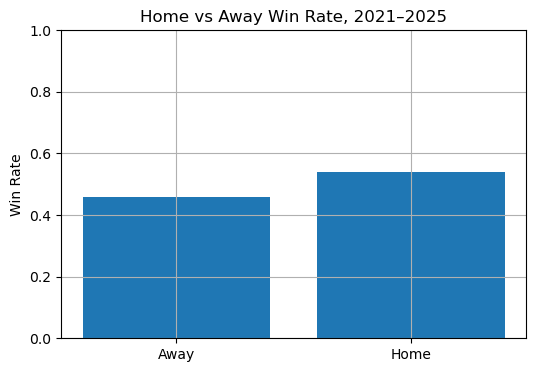

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(home_win_rates["location"], home_win_rates["team_win"])
plt.ylabel("Win Rate")
plt.title("Home vs Away Win Rate, 2021–2025")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

### Point differential entering game 

In [147]:
modeling_df["pd_diff_bin"] = pd.qcut(
    modeling_df["pd_pg_diff_entering"],
    q=10,
    duplicates="drop"
)

In [148]:
pd_bin_summary = (
    modeling_df
    .groupby("pd_diff_bin")
    .agg(
        win_rate=("team_win", "mean"),
        avg_pd_diff=("pd_pg_diff_entering", "mean"),
        games=("team_win", "size")
    )
    .reset_index()
)

pd_bin_summary

,pd_diff_bin,win_rate,avg_pd_diff,games
0,"(-49.001, -12.411]",0.326007,-17.857995,273
1,"(-12.411, -7.727]",0.338235,-9.871994,272
2,"(-7.727, -4.392]",0.372694,-5.917198,271
3,"(-4.392, -1.667]",0.485294,-2.994754,272
4,"(-1.667, 0.0]",0.526316,-0.429915,361
5,"(0.0, 1.667]",0.437158,0.866299,183
6,"(1.667, 4.392]",0.514815,3.004592,270
7,"(4.392, 7.727]",0.630037,5.930458,273
8,"(7.727, 12.411]",0.661765,9.906434,272
9,"(12.411, 49.0]",0.664207,17.898193,271


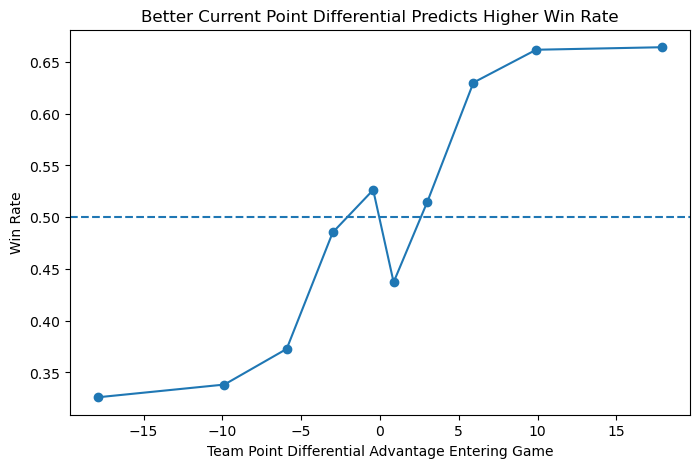

In [149]:
plt.figure(figsize=(8, 5))
plt.plot(pd_bin_summary["avg_pd_diff"], pd_bin_summary["win_rate"], marker="o")
plt.axhline(0.5, linestyle="--")
plt.xlabel("Team Point Differential Advantage Entering Game")
plt.ylabel("Win Rate")
plt.title("Better Current Point Differential Predicts Higher Win Rate")
plt.show()

### Previous season strength

In [150]:
modeling_df["prev_pd_diff_bin"] = pd.qcut(
    modeling_df["prev_pd_pg_diff"],
    q=10,
    duplicates="drop"
)

In [151]:
prev_pd_bin_summary = (
    modeling_df
    .groupby("prev_pd_diff_bin")
    .agg(
        win_rate=("team_win", "mean"),
        avg_prev_pd_diff=("prev_pd_pg_diff", "mean"),
        games=("team_win", "size")
    )
    .reset_index()
)

prev_pd_bin_summary

,prev_pd_diff_bin,win_rate,avg_prev_pd_diff,games
0,"(-23.472, -9.765]",0.366300,-13.578243,273
1,"(-9.765, -5.506]",0.394834,-7.486149,271
2,"(-5.506, -2.524]",0.474265,-3.852563,272
3,"(-2.524, 0.0]",0.477467,-0.404457,821
4,"(0.0, 2.524]",0.566038,1.253052,265
5,"(2.524, 5.506]",0.525735,3.852563,272
6,"(5.506, 9.765]",0.596364,7.519291,275
7,"(9.765, 23.471]",0.631970,13.634950,269


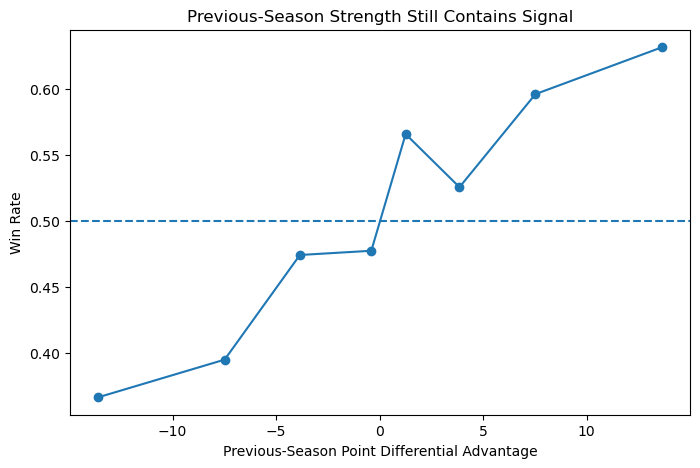

In [152]:
plt.figure(figsize=(8, 5))
plt.plot(prev_pd_bin_summary["avg_prev_pd_diff"], prev_pd_bin_summary["win_rate"], marker="o")
plt.axhline(0.5, linestyle="--")
plt.xlabel("Previous-Season Point Differential Advantage")
plt.ylabel("Win Rate")
plt.title("Previous-Season Strength Still Contains Signal")
plt.show()

### Is blended strength better? 

In [153]:
modeling_df["blended_pd_diff_bin"] = pd.qcut(
    modeling_df["blended_pd_pg_diff"],
    q=10,
    duplicates="drop"
)

In [154]:
blended_bin_summary = (
    modeling_df
    .groupby("blended_pd_diff_bin")
    .agg(
        win_rate=("team_win", "mean"),
        avg_blended_diff=("blended_pd_pg_diff", "mean"),
        games=("team_win", "size")
    )
    .reset_index()
)

blended_bin_summary

,blended_pd_diff_bin,win_rate,avg_blended_diff,games
0,"(-23.741, -9.362]",0.290441,-13.021828,272
1,"(-9.362, -6.118]",0.300366,-7.683576,273
2,"(-6.118, -3.578]",0.350554,-4.789907,271
3,"(-3.578, -1.778]",0.453875,-2.637553,271
4,"(-1.778, 0.0]",0.500000,-0.765805,290
5,"(0.0, 1.778]",0.500000,0.874344,254
6,"(1.778, 3.578]",0.542435,2.637553,271
7,"(3.578, 6.118]",0.649635,4.804444,274
8,"(6.118, 9.362]",0.696296,7.700976,270
9,"(9.362, 23.74]",0.702206,13.021828,272


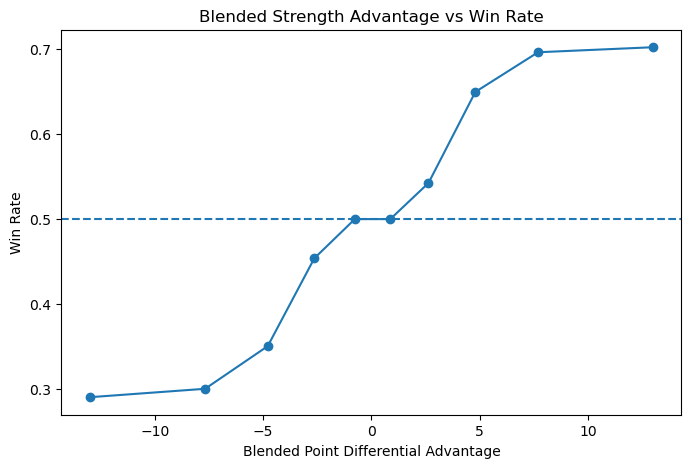

In [155]:
plt.figure(figsize=(8, 5))
plt.plot(blended_bin_summary["avg_blended_diff"], blended_bin_summary["win_rate"], marker="o")
plt.axhline(0.5, linestyle="--")
plt.xlabel("Blended Point Differential Advantage")
plt.ylabel("Win Rate")
plt.title("Blended Strength Advantage vs Win Rate")
plt.show()

In [156]:
eda_features = [
    "is_home",
    "team_win_pct_entering",
    "opp_win_pct_entering",
    "win_pct_diff_entering",
    "team_pd_pg_entering",
    "opp_pd_pg_entering",
    "pd_pg_diff_entering",
    "team_prev_win_pct",
    "opp_prev_win_pct",
    "prev_win_pct_diff",
    "team_prev_pd_pg",
    "opp_prev_pd_pg",
    "prev_pd_pg_diff",
    "team_blended_pd_pg",
    "opp_blended_pd_pg",
    "blended_pd_pg_diff"
]

corrs = (
    modeling_df[eda_features + ["team_win"]]
    .corr(numeric_only=True)["team_win"]
    .drop("team_win")
    .sort_values()
)

corrs

opp_blended_pd_pg       -0.191821
opp_pd_pg_entering      -0.144534
opp_win_pct_entering    -0.134777
opp_prev_pd_pg          -0.105104
opp_prev_win_pct        -0.101624
is_home                  0.081678
team_prev_win_pct        0.103648
team_prev_pd_pg          0.107106
team_win_pct_entering    0.135247
team_pd_pg_entering      0.146043
prev_win_pct_diff        0.151210
prev_pd_pg_diff          0.152838
win_pct_diff_entering    0.194027
team_blended_pd_pg       0.194275
pd_pg_diff_entering      0.212724
blended_pd_pg_diff       0.279837
Name: team_win, dtype: float64

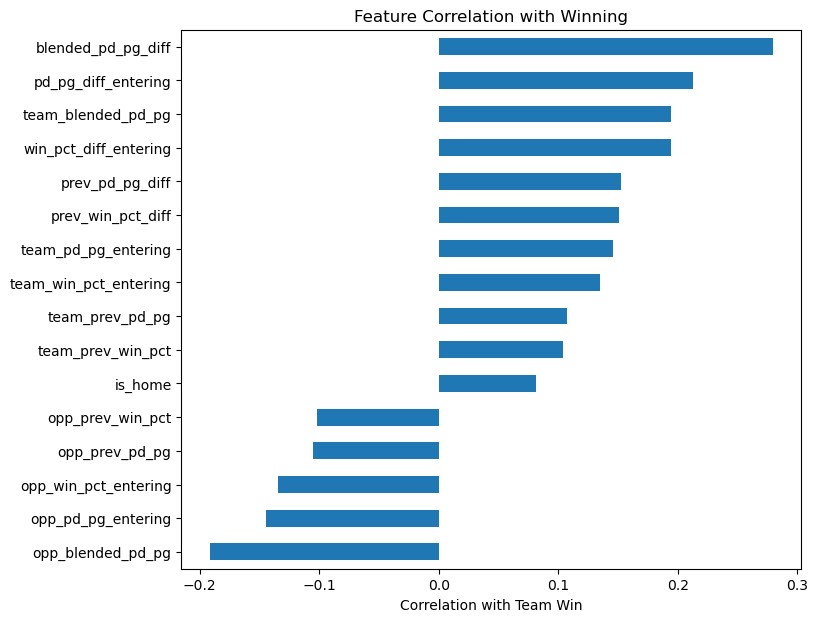

In [157]:
plt.figure(figsize=(8, 7))
corrs.plot(kind="barh")
plt.xlabel("Correlation with Team Win")
plt.title("Feature Correlation with Winning")
plt.show()

In [158]:
modeling_df["season_phase"] = pd.cut(
    modeling_df["week"],
    bins=[0, 4, 9, 18],
    labels=["Early Weeks 1–4", "Middle Weeks 5–9", "Late Weeks 10–18"]
)

In [159]:
phase_corrs = []

for phase, df_phase in modeling_df.groupby("season_phase"):
    phase_corrs.append({
        "season_phase": phase,
        "corr_prev_pd_diff": df_phase["prev_pd_pg_diff"].corr(df_phase["team_win"]),
        "corr_current_pd_diff": df_phase["pd_pg_diff_entering"].corr(df_phase["team_win"]),
        "corr_blended_pd_diff": df_phase["blended_pd_pg_diff"].corr(df_phase["team_win"])
    })

phase_corrs = pd.DataFrame(phase_corrs)

phase_corrs

,season_phase,corr_prev_pd_diff,corr_current_pd_diff,corr_blended_pd_diff
0,Early Weeks 1–4,0.248958,0.013608,0.208220
1,Middle Weeks 5–9,0.150574,0.226455,0.244982
2,Late Weeks 10–18,0.107622,0.341527,0.333258


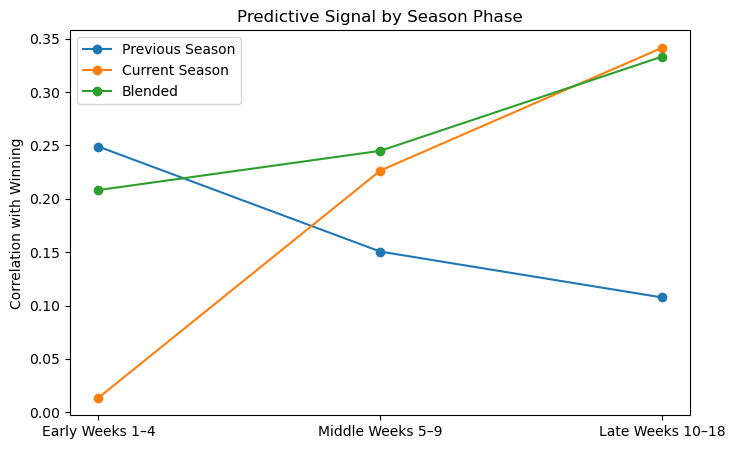

In [160]:
phase_corrs_plot = phase_corrs.set_index("season_phase")

plt.figure(figsize=(8, 5))
plt.plot(phase_corrs_plot.index, phase_corrs_plot["corr_prev_pd_diff"], marker="o", label="Previous Season")
plt.plot(phase_corrs_plot.index, phase_corrs_plot["corr_current_pd_diff"], marker="o", label="Current Season")
plt.plot(phase_corrs_plot.index, phase_corrs_plot["corr_blended_pd_diff"], marker="o", label="Blended")
plt.ylabel("Correlation with Winning")
plt.title("Predictive Signal by Season Phase")
plt.legend()
plt.show()

In [161]:
df_2025 = modeling_df[modeling_df["season"] == 2025].copy()

df_2025.shape

(544, 80)

In [162]:
corrs_2025 = (
    df_2025[eda_features + ["team_win"]]
    .corr(numeric_only=True)["team_win"]
    .drop("team_win")
    .sort_values()
)

corrs_2025

opp_blended_pd_pg       -0.225463
opp_pd_pg_entering      -0.200140
opp_win_pct_entering    -0.191444
opp_prev_win_pct        -0.114367
opp_prev_pd_pg          -0.111263
is_home                  0.077206
team_prev_pd_pg          0.111130
team_prev_win_pct        0.113359
prev_pd_pg_diff          0.162194
prev_win_pct_diff        0.168881
team_win_pct_entering    0.191454
team_pd_pg_entering      0.199810
team_blended_pd_pg       0.225217
win_pct_diff_entering    0.273743
pd_pg_diff_entering      0.288892
blended_pd_pg_diff       0.326260
Name: team_win, dtype: float64

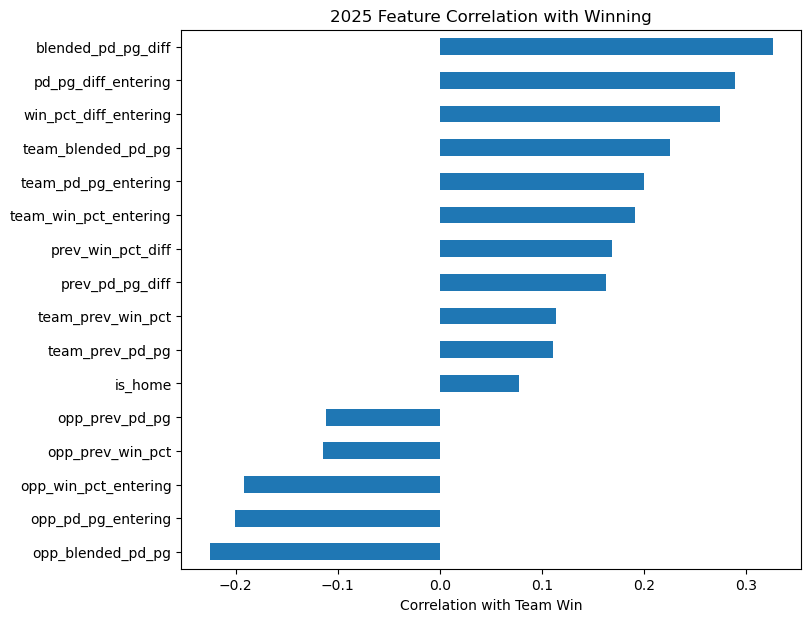

In [163]:
plt.figure(figsize=(8, 7))
corrs_2025.plot(kind="barh")
plt.xlabel("Correlation with Team Win")
plt.title("2025 Feature Correlation with Winning")
plt.show()

In [164]:
pd_bin_summary.to_csv("eda_current_pd_diff_bins.csv", index=False)
prev_pd_bin_summary.to_csv("eda_prev_pd_diff_bins.csv", index=False)
blended_bin_summary.to_csv("eda_blended_pd_diff_bins.csv", index=False)
phase_corrs.to_csv("eda_phase_correlations.csv", index=False)

In [165]:
modeling_df.to_csv("modeling_df_eda_2021_2025.csv", index=False)

In [166]:
test_eda = pd.read_csv("modeling_df_eda_2021_2025.csv")
test_eda.shape

(2718, 80)

## EDA Summary

The exploratory analysis confirmed that the engineered pre-game features have clear football signal. Teams with better point differential entering a game won more often, and teams with stronger previous-season performance also showed higher win rates. Home teams had a modest win-rate advantage. The blended strength feature is especially useful because it combines previous-season information early in the year with current-season information as more games are played.

These results support using rolling team strength, previous-season priors, home field, and team-vs-opponent difference features in the predictive model.

In [167]:
modeling_df = pd.read_csv("modeling_df_with_priors_2021_2025.csv")

modeling_df.shape

(2718, 75)

In [168]:
modeling_df.head()

,game_id,season,week,day,date,time,team,opponent,is_home,team_score,...,opp_prev_pd_pg,prev_win_pct_diff,prev_pd_pg_diff,prev_pf_pg_diff,prev_pa_pg_diff,current_weight,team_blended_pd_pg,opp_current_weight,opp_blended_pd_pg,blended_pd_pg_diff
0,2021_1.0_2021-09-12_1:00PM_Arizona Cardinals_a...,2021,1.0,Sun,2021-09-12,1:00PM,Arizona Cardinals,Tennessee Titans,0,38,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,2021_2.0_2021-09-19_4:05PM_Minnesota Vikings_a...,2021,2.0,Sun,2021-09-19,4:05PM,Arizona Cardinals,Minnesota Vikings,1,34,...,0.0,0.0,0.0,0.0,0.0,0.200000,5.000000,0.200000,-0.600000,5.600000
2,2021_3.0_2021-09-26_1:00PM_Arizona Cardinals_a...,2021,3.0,Sun,2021-09-26,1:00PM,Arizona Cardinals,Jacksonville Jaguars,0,31,...,0.0,0.0,0.0,0.0,0.0,0.333333,4.333333,0.333333,-4.333333,8.666667
3,2021_4.0_2021-10-03_4:05PM_Arizona Cardinals_a...,2021,4.0,Sun,2021-10-03,4:05PM,Arizona Cardinals,Los Angeles Rams,0,37,...,0.0,0.0,0.0,0.0,0.0,0.428571,5.428571,0.428571,4.714286,0.714286
4,2021_5.0_2021-10-10_4:25PM_San Francisco 49ers...,2021,5.0,Sun,2021-10-10,4:25PM,Arizona Cardinals,San Francisco 49ers,1,17,...,0.0,0.0,0.0,0.0,0.0,0.500000,6.875000,0.500000,0.625000,6.250000


In [169]:
!pip install scikit-learn

In [170]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

In [171]:
feature_cols = [
    "is_home",
    
    "win_pct_diff_entering",
    "pd_pg_diff_entering",
    "pf_pg_diff_entering",
    "pa_pg_diff_entering",
    
    "prev_win_pct_diff",
    "prev_pd_pg_diff",
    "prev_pf_pg_diff",
    "prev_pa_pg_diff",
    
    "blended_pd_pg_diff"
]

In [172]:
target_col = "team_win"

In [173]:
model_df = modeling_df[modeling_df["team_tie"] == 0].copy()

model_df.shape

(2710, 75)

In [174]:
model_df["team_win"].value_counts()

1    1355
0    1355
Name: team_win, dtype: int64

In [175]:
train_df = model_df[model_df["season"].isin([2021, 2022, 2023])].copy()
val_df = model_df[model_df["season"] == 2024].copy()
test_df = model_df[model_df["season"] == 2025].copy()

In [176]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (1624, 75)
Validation: (544, 75)
Test: (542, 75)


In [177]:
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

In [178]:
X_train.isna().sum()

is_home                  0
win_pct_diff_entering    0
pd_pg_diff_entering      0
pf_pg_diff_entering      0
pa_pg_diff_entering      0
prev_win_pct_diff        0
prev_pd_pg_diff          0
prev_pf_pg_diff          0
prev_pa_pg_diff          0
blended_pd_pg_diff       0
dtype: int64

In [179]:
X_val.isna().sum()
X_test.isna().sum()

is_home                  0
win_pct_diff_entering    0
pd_pg_diff_entering      0
pf_pg_diff_entering      0
pa_pg_diff_entering      0
prev_win_pct_diff        0
prev_pd_pg_diff          0
prev_pf_pg_diff          0
prev_pa_pg_diff          0
blended_pd_pg_diff       0
dtype: int64

In [180]:
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [181]:
val_pred_prob = log_model.predict_proba(X_val)[:, 1]
val_pred_class = (val_pred_prob >= 0.5).astype(int)

In [182]:
val_accuracy = accuracy_score(y_val, val_pred_class)
val_log_loss = log_loss(y_val, val_pred_prob)
val_brier = brier_score_loss(y_val, val_pred_prob)
val_auc = roc_auc_score(y_val, val_pred_prob)

print("2024 Validation Results")
print("Accuracy:", round(val_accuracy, 3))
print("Log Loss:", round(val_log_loss, 3))
print("Brier Score:", round(val_brier, 3))
print("ROC AUC:", round(val_auc, 3))

2024 Validation Results
Accuracy: 0.673
Log Loss: 0.626
Brier Score: 0.218
ROC AUC: 0.709


In [183]:
baseline_prob = np.where(val_df["is_home"] == 1, 0.55, 0.45)
baseline_class = (baseline_prob >= 0.5).astype(int)

baseline_accuracy = accuracy_score(y_val, baseline_class)
baseline_log_loss = log_loss(y_val, baseline_prob)
baseline_brier = brier_score_loss(y_val, baseline_prob)
baseline_auc = roc_auc_score(y_val, baseline_prob)

print("2024 Baseline Results")
print("Accuracy:", round(baseline_accuracy, 3))
print("Log Loss:", round(baseline_log_loss, 3))
print("Brier Score:", round(baseline_brier, 3))
print("ROC AUC:", round(baseline_auc, 3))

2024 Baseline Results
Accuracy: 0.533
Log Loss: 0.692
Brier Score: 0.249
ROC AUC: 0.533


In [184]:
test_pred_prob = log_model.predict_proba(X_test)[:, 1]
test_pred_class = (test_pred_prob >= 0.5).astype(int)

In [185]:
test_accuracy = accuracy_score(y_test, test_pred_class)
test_log_loss = log_loss(y_test, test_pred_prob)
test_brier = brier_score_loss(y_test, test_pred_prob)
test_auc = roc_auc_score(y_test, test_pred_prob)

print("2025 Test Results")
print("Accuracy:", round(test_accuracy, 3))
print("Log Loss:", round(test_log_loss, 3))
print("Brier Score:", round(test_brier, 3))
print("ROC AUC:", round(test_auc, 3))

2025 Test Results
Accuracy: 0.601
Log Loss: 0.652
Brier Score: 0.231
ROC AUC: 0.654


In [186]:
model_df = model_df.copy()
model_df["pred_win_prob"] = np.nan

In [187]:
model_df.loc[val_df.index, "pred_win_prob"] = val_pred_prob

In [188]:
model_df.loc[test_df.index, "pred_win_prob"] = test_pred_prob

In [189]:
train_pred_prob = log_model.predict_proba(X_train)[:, 1]
model_df.loc[train_df.index, "pred_win_prob"] = train_pred_prob

In [190]:
model_df["pred_win_prob"].isna().sum()

0

In [191]:
model_df[[
    "season", "week", "team", "opponent", "is_home",
    "team_win", "pred_win_prob",
    "blended_pd_pg_diff"
]].head(20)

,season,week,team,opponent,is_home,team_win,pred_win_prob,blended_pd_pg_diff
0,2021,1.0,Arizona Cardinals,Tennessee Titans,0,1,0.449136,0.000000
1,2021,2.0,Arizona Cardinals,Minnesota Vikings,1,1,0.440378,5.600000
2,2021,3.0,Arizona Cardinals,Jacksonville Jaguars,0,1,0.529932,8.666667
3,2021,4.0,Arizona Cardinals,Los Angeles Rams,0,1,0.477955,0.714286
4,2021,5.0,Arizona Cardinals,San Francisco 49ers,1,1,0.644312,6.250000
5,2021,6.0,Arizona Cardinals,Cleveland Browns,0,1,0.494087,3.777778
6,2021,7.0,Arizona Cardinals,Houston Texans,1,1,0.802162,16.500000
7,2021,8.0,Arizona Cardinals,Green Bay Packers,1,0,0.701601,8.090909
8,2021,9.0,Arizona Cardinals,San Francisco 49ers,0,1,0.606799,9.272727
9,2021,10.0,Arizona Cardinals,Carolina Panthers,1,0,0.760579,10.307692


In [192]:
model_df[model_df["season"] == 2025][[
    "week", "team", "opponent", "is_home",
    "team_win", "pred_win_prob",
    "blended_pd_pg_diff"
]].head(20)

,week,team,opponent,is_home,team_win,pred_win_prob,blended_pd_pg_diff
2174,1.0,Arizona Cardinals,New Orleans Saints,0,1,0.583040,4.764706
2175,2.0,Arizona Cardinals,Carolina Panthers,1,1,0.682372,14.670588
2176,3.0,Arizona Cardinals,San Francisco 49ers,0,0,0.516450,3.166667
2177,4.0,Arizona Cardinals,Seattle Seahawks,1,0,0.500741,-3.815126
2178,5.0,Arizona Cardinals,Tennessee Titans,1,0,0.734054,14.625000
2179,6.0,Arizona Cardinals,Indianapolis Colts,0,0,0.330134,-5.588235
2180,7.0,Arizona Cardinals,Green Bay Packers,1,0,0.436194,-5.617647
2181,9.0,Arizona Cardinals,Dallas Cowboys,0,1,0.403840,3.005348
2182,10.0,Arizona Cardinals,Seattle Seahawks,0,0,0.359125,-5.725490
2183,11.0,Arizona Cardinals,San Francisco 49ers,1,0,0.560759,0.884292


In [193]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": log_model.named_steps["model"].coef_[0]
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
9,blended_pd_pg_diff,0.931754
4,pa_pg_diff_entering,0.288094
0,is_home,0.204164
8,prev_pa_pg_diff,0.084491
7,prev_pf_pg_diff,0.040613
3,pf_pg_diff_entering,0.011006
6,prev_pd_pg_diff,-0.012006
1,win_pct_diff_entering,-0.031880
5,prev_win_pct_diff,-0.096248
2,pd_pg_diff_entering,-0.173306


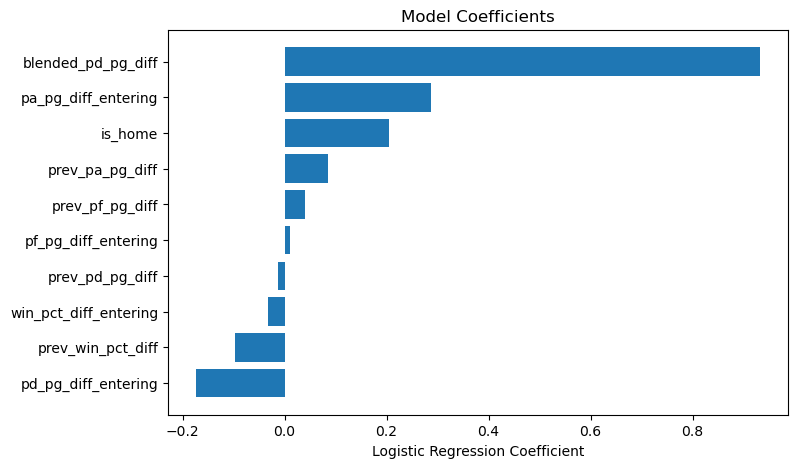

In [194]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(coef_df["feature"], coef_df["coefficient"])
plt.xlabel("Logistic Regression Coefficient")
plt.title("Model Coefficients")
plt.gca().invert_yaxis()
plt.show()

In [195]:
model_df.to_csv("game_predictions_logistic_2021_2025.csv", index=False)

In [196]:
coef_df.to_csv("logistic_model_coefficients.csv", index=False)

In [197]:
test_preds = pd.read_csv("game_predictions_logistic_2021_2025.csv")
test_preds.shape

(2710, 76)

## Step 7 Model Summary

I trained a logistic regression model to predict whether a team wins a game using only pre-game information. The model used home field, current-season rolling strength, previous-season strength, and a blended current/prior strength feature. Tied games were removed for this first binary model.

The model was trained on 2021–2023, validated on 2024, and tested on 2025. This gives a clean time-based evaluation and avoids training on future information.

#### model improvement

In [198]:
modeling_df = pd.read_csv("modeling_df_with_priors_2021_2025.csv")

modeling_df.shape

(2718, 75)

In [199]:
model_df = modeling_df[modeling_df["team_tie"] == 0].copy()

model_df.shape

(2710, 75)

In [200]:
model_df["week_num"] = model_df["week"].astype(float)

model_df["home_blended_interaction"] = (
    model_df["is_home"] * model_df["blended_pd_pg_diff"]
)

model_df["home_prev_interaction"] = (
    model_df["is_home"] * model_df["prev_pd_pg_diff"]
)

model_df["abs_blended_diff"] = (
    model_df["blended_pd_pg_diff"].abs()
)

In [201]:
feature_cols_improved = [
    "is_home",
    "week_num",

    "team_games_played_entering",
    "opp_games_played_entering",

    "win_pct_diff_entering",
    "pd_pg_diff_entering",
    "pf_pg_diff_entering",
    "pa_pg_diff_entering",

    "prev_win_pct_diff",
    "prev_pd_pg_diff",
    "prev_pf_pg_diff",
    "prev_pa_pg_diff",

    "blended_pd_pg_diff",
    "home_blended_interaction",
    "home_prev_interaction",
    "abs_blended_diff"
]

In [202]:
model_df[feature_cols_improved].isna().sum()

is_home                       0
week_num                      0
team_games_played_entering    0
opp_games_played_entering     0
win_pct_diff_entering         0
pd_pg_diff_entering           0
pf_pg_diff_entering           0
pa_pg_diff_entering           0
prev_win_pct_diff             0
prev_pd_pg_diff               0
prev_pf_pg_diff               0
prev_pa_pg_diff               0
blended_pd_pg_diff            0
home_blended_interaction      0
home_prev_interaction         0
abs_blended_diff              0
dtype: int64

In [203]:
train_df = model_df[model_df["season"].isin([2021, 2022, 2023])].copy()
val_df = model_df[model_df["season"] == 2024].copy()
test_df = model_df[model_df["season"] == 2025].copy()

X_train = train_df[feature_cols_improved]
y_train = train_df["team_win"]

X_val = val_df[feature_cols_improved]
y_val = val_df["team_win"]

X_test = test_df[feature_cols_improved]
y_test = test_df["team_win"]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1624, 16)
Validation: (544, 16)
Test: (542, 16)


In [204]:
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score

def evaluate_model(name, model, X, y):
    pred_prob = model.predict_proba(X)[:, 1]
    pred_class = (pred_prob >= 0.5).astype(int)

    return {
        "model": name,
        "accuracy": accuracy_score(y, pred_class),
        "log_loss": log_loss(y, pred_prob),
        "brier": brier_score_loss(y, pred_prob),
        "auc": roc_auc_score(y, pred_prob)
    }

In [205]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

C_values = [0.01, 0.03, 0.1, 0.3, 1, 3, 10]

log_results = []
log_models = {}

for C in C_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, C=C))
    ])

    model.fit(X_train, y_train)

    name = f"Logistic_C_{C}"
    log_models[name] = model

    result = evaluate_model(name, model, X_val, y_val)
    log_results.append(result)

log_results_df = pd.DataFrame(log_results).sort_values("log_loss")
log_results_df

,model,accuracy,log_loss,brier,auc
6,Logistic_C_10,0.672794,0.625075,0.217254,0.711046
5,Logistic_C_3,0.672794,0.625262,0.217345,0.710870
4,Logistic_C_1,0.674632,0.625686,0.217546,0.710397
3,Logistic_C_0.3,0.678309,0.626537,0.217950,0.709248
2,Logistic_C_0.1,0.680147,0.628148,0.218687,0.707275
1,Logistic_C_0.03,0.674632,0.630895,0.219888,0.706774
0,Logistic_C_0.01,0.667279,0.634027,0.221245,0.708031


In [206]:
best_log_name = log_results_df.iloc[0]["model"]
best_log_model = log_models[best_log_name]

best_log_name

'Logistic_C_10'

In [207]:
best_log_val = evaluate_model(best_log_name + "_VAL_2024", best_log_model, X_val, y_val)
best_log_test = evaluate_model(best_log_name + "_TEST_2025", best_log_model, X_test, y_test)

best_log_val, best_log_test

({'model': 'Logistic_C_10_VAL_2024',
  'accuracy': 0.6727941176470589,
  'log_loss': 0.6250746660806971,
  'brier': 0.21725449021928153,
  'auc': 0.7110456314878892},
 {'model': 'Logistic_C_10_TEST_2025',
  'accuracy': 0.6051660516605166,
  'log_loss': 0.6519989497490098,
  'brier': 0.23087293281925028,
  'auc': 0.6543483885023353})

In [208]:
from sklearn.ensemble import RandomForestClassifier

rf_models = {}
rf_results = []

rf_settings = [
    {"n_estimators": 200, "max_depth": 3, "min_samples_leaf": 20},
    {"n_estimators": 300, "max_depth": 4, "min_samples_leaf": 15},
    {"n_estimators": 400, "max_depth": 5, "min_samples_leaf": 10},
    {"n_estimators": 500, "max_depth": 6, "min_samples_leaf": 10},
]

for i, params in enumerate(rf_settings):
    model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        random_state=42
    )

    model.fit(X_train, y_train)

    name = f"RF_{i}"
    rf_models[name] = model

    result = evaluate_model(name, model, X_val, y_val)
    result.update(params)
    rf_results.append(result)

rf_results_df = pd.DataFrame(rf_results).sort_values("log_loss")
rf_results_df

,model,accuracy,log_loss,brier,auc,n_estimators,max_depth,min_samples_leaf
1,RF_1,0.665441,0.627999,0.218328,0.716222,300,4,15
2,RF_2,0.661765,0.629383,0.218952,0.712870,400,5,10
0,RF_0,0.669118,0.629441,0.218903,0.717155,200,3,20
3,RF_3,0.661765,0.630844,0.219568,0.707018,500,6,10


In [209]:
best_rf_name = rf_results_df.iloc[0]["model"]
best_rf_model = rf_models[best_rf_name]

best_rf_val = evaluate_model(best_rf_name + "_VAL_2024", best_rf_model, X_val, y_val)
best_rf_test = evaluate_model(best_rf_name + "_TEST_2025", best_rf_model, X_test, y_test)

best_rf_val, best_rf_test

({'model': 'RF_1_VAL_2024',
  'accuracy': 0.6654411764705882,
  'log_loss': 0.6279985783244607,
  'brier': 0.21832783864687974,
  'auc': 0.7162224264705881},
 {'model': 'RF_1_TEST_2025',
  'accuracy': 0.5885608856088561,
  'log_loss': 0.6518390701893725,
  'brier': 0.23011181838789121,
  'auc': 0.669557876390572})

In [210]:
from sklearn.ensemble import GradientBoostingClassifier

gb_models = {}
gb_results = []

gb_settings = [
    {"n_estimators": 50, "learning_rate": 0.03, "max_depth": 2},
    {"n_estimators": 75, "learning_rate": 0.03, "max_depth": 2},
    {"n_estimators": 100, "learning_rate": 0.03, "max_depth": 2},
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 2},
    {"n_estimators": 150, "learning_rate": 0.03, "max_depth": 2},
    {"n_estimators": 100, "learning_rate": 0.03, "max_depth": 3},
]

for i, params in enumerate(gb_settings):
    model = GradientBoostingClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        random_state=42
    )

    model.fit(X_train, y_train)

    name = f"GB_{i}"
    gb_models[name] = model

    result = evaluate_model(name, model, X_val, y_val)
    result.update(params)
    gb_results.append(result)

gb_results_df = pd.DataFrame(gb_results).sort_values("log_loss")
gb_results_df

,model,accuracy,log_loss,brier,auc,n_estimators,learning_rate,max_depth
2,GB_2,0.667279,0.636246,0.222133,0.702557,100,0.03,2
1,GB_1,0.661765,0.636336,0.222140,0.706673,75,0.03,2
0,GB_0,0.674632,0.639469,0.223586,0.708505,50,0.03,2
3,GB_3,0.669118,0.639685,0.223778,0.690575,100,0.05,2
4,GB_4,0.667279,0.639792,0.223839,0.689636,150,0.03,2
5,GB_5,0.658088,0.646185,0.226889,0.675274,100,0.03,3


In [211]:
best_gb_name = gb_results_df.iloc[0]["model"]
best_gb_model = gb_models[best_gb_name]

best_gb_val = evaluate_model(best_gb_name + "_VAL_2024", best_gb_model, X_val, y_val)
best_gb_test = evaluate_model(best_gb_name + "_TEST_2025", best_gb_model, X_test, y_test)

best_gb_val, best_gb_test

({'model': 'GB_2_VAL_2024',
  'accuracy': 0.6672794117647058,
  'log_loss': 0.6362455751208536,
  'brier': 0.22213277612055532,
  'auc': 0.7025573096885812},
 {'model': 'GB_2_TEST_2025',
  'accuracy': 0.584870848708487,
  'log_loss': 0.6557017937821438,
  'brier': 0.232169113169301,
  'auc': 0.6527961220571615})

In [212]:
comparison = pd.DataFrame([
    best_log_val,
    best_log_test,
    best_rf_val,
    best_rf_test,
    best_gb_val,
    best_gb_test
])

comparison

,model,accuracy,log_loss,brier,auc
0,Logistic_C_10_VAL_2024,0.672794,0.625075,0.217254,0.711046
1,Logistic_C_10_TEST_2025,0.605166,0.651999,0.230873,0.654348
2,RF_1_VAL_2024,0.665441,0.627999,0.218328,0.716222
3,RF_1_TEST_2025,0.588561,0.651839,0.230112,0.669558
4,GB_2_VAL_2024,0.667279,0.636246,0.222133,0.702557
5,GB_2_TEST_2025,0.584871,0.655702,0.232169,0.652796


In [213]:
comparison.sort_values(["model"])

,model,accuracy,log_loss,brier,auc
5,GB_2_TEST_2025,0.584871,0.655702,0.232169,0.652796
4,GB_2_VAL_2024,0.667279,0.636246,0.222133,0.702557
1,Logistic_C_10_TEST_2025,0.605166,0.651999,0.230873,0.654348
0,Logistic_C_10_VAL_2024,0.672794,0.625075,0.217254,0.711046
3,RF_1_TEST_2025,0.588561,0.651839,0.230112,0.669558
2,RF_1_VAL_2024,0.665441,0.627999,0.218328,0.716222


In [214]:
all_val_results = pd.concat([
    log_results_df,
    rf_results_df,
    gb_results_df
], ignore_index=True)

all_val_results.sort_values("log_loss").head(10)

,model,accuracy,log_loss,brier,auc,n_estimators,max_depth,min_samples_leaf,learning_rate
0,Logistic_C_10,0.672794,0.625075,0.217254,0.711046,NaN,NaN,NaN,NaN
1,Logistic_C_3,0.672794,0.625262,0.217345,0.710870,NaN,NaN,NaN,NaN
2,Logistic_C_1,0.674632,0.625686,0.217546,0.710397,NaN,NaN,NaN,NaN
3,Logistic_C_0.3,0.678309,0.626537,0.217950,0.709248,NaN,NaN,NaN,NaN
7,RF_1,0.665441,0.627999,0.218328,0.716222,300.0,4.0,15.0,NaN
4,Logistic_C_0.1,0.680147,0.628148,0.218687,0.707275,NaN,NaN,NaN,NaN
8,RF_2,0.661765,0.629383,0.218952,0.712870,400.0,5.0,10.0,NaN
9,RF_0,0.669118,0.629441,0.218903,0.717155,200.0,3.0,20.0,NaN
10,RF_3,0.661765,0.630844,0.219568,0.707018,500.0,6.0,10.0,NaN
5,Logistic_C_0.03,0.674632,0.630895,0.219888,0.706774,NaN,NaN,NaN,NaN


In [215]:
final_model_type = "logistic"
final_model_name = best_log_name
final_model = best_log_model

In [216]:
final_val_results = evaluate_model(final_model_name + "_VAL_2024", final_model, X_val, y_val)
final_test_results = evaluate_model(final_model_name + "_TEST_2025", final_model, X_test, y_test)

final_results = pd.DataFrame([final_val_results, final_test_results])
final_results

,model,accuracy,log_loss,brier,auc
0,Logistic_C_10_VAL_2024,0.672794,0.625075,0.217254,0.711046
1,Logistic_C_10_TEST_2025,0.605166,0.651999,0.230873,0.654348


In [217]:
model_df_improved = model_df.copy()

model_df_improved["pred_win_prob_improved"] = np.nan

model_df_improved.loc[train_df.index, "pred_win_prob_improved"] = final_model.predict_proba(X_train)[:, 1]
model_df_improved.loc[val_df.index, "pred_win_prob_improved"] = final_model.predict_proba(X_val)[:, 1]
model_df_improved.loc[test_df.index, "pred_win_prob_improved"] = final_model.predict_proba(X_test)[:, 1]

model_df_improved["pred_win_prob_improved"].isna().sum()

0

In [218]:
model_df_improved["pred_win_prob_improved"].describe()

count    2710.000000
mean        0.500006
std         0.152505
min         0.040652
25%         0.391668
50%         0.499988
75%         0.608407
max         0.959357
Name: pred_win_prob_improved, dtype: float64

In [219]:
if final_model_type == "logistic":
    importance_df = pd.DataFrame({
        "feature": feature_cols_improved,
        "coefficient": final_model.named_steps["model"].coef_[0]
    }).sort_values("coefficient", ascending=False)

    importance_df

In [220]:
model_df_improved.to_csv("game_predictions_improved_2021_2025.csv", index=False)

final_results.to_csv("improved_model_results.csv", index=False)

all_val_results.to_csv("model_tuning_validation_results.csv", index=False)

In [221]:
test_improved = pd.read_csv("game_predictions_improved_2021_2025.csv")
test_improved.shape

(2710, 80)

This tested whether additional feature engineering and more complex models could improve performance. Tuned logistic regression achieved the best 2024 validation log loss, while random forest and gradient boosting did not provide a strong enough improvement to justify reduced interpretability. I therefore selected the tuned logistic model as the final game win-probability model.

In [222]:
game_preds = pd.read_csv("game_predictions_improved_2021_2025.csv")

game_preds.shape

(2710, 80)

In [223]:
game_preds.columns

Index(['game_id', 'season', 'week', 'day', 'date', 'time', 'team', 'opponent',
       'is_home', 'team_score', 'opp_score', 'team_win', 'team_loss',
       'team_tie', 'team_margin', 'points_for', 'points_against', 'point_diff',
       'cum_wins', 'cum_losses', 'cum_ties', 'cum_points_for',
       'cum_points_against', 'cum_point_diff', 'team_wins_entering',
       'team_losses_entering', 'team_ties_entering',
       'team_points_for_entering', 'team_points_against_entering',
       'team_point_diff_entering', 'team_games_played_entering',
       'team_win_pct_entering', 'team_pf_pg_entering', 'team_pa_pg_entering',
       'team_pd_pg_entering', 'opp_wins_entering', 'opp_losses_entering',
       'opp_ties_entering', 'opp_games_played_entering',
       'opp_win_pct_entering', 'opp_pf_pg_entering', 'opp_pa_pg_entering',
       'opp_pd_pg_entering', 'win_pct_diff_entering', 'pd_pg_diff_entering',
       'pf_pg_diff_entering', 'pa_pg_diff_entering', 'team_prev_wins',
       'team_prev_loss

In [224]:
game_preds[["season", "week", "team", "opponent", "team_win", "pred_win_prob_improved"]].head()

,season,week,team,opponent,team_win,pred_win_prob_improved
0,2021,1.0,Arizona Cardinals,Tennessee Titans,1,0.449094
1,2021,2.0,Arizona Cardinals,Minnesota Vikings,1,0.432400
2,2021,3.0,Arizona Cardinals,Jacksonville Jaguars,1,0.525266
3,2021,4.0,Arizona Cardinals,Los Angeles Rams,1,0.477805
4,2021,5.0,Arizona Cardinals,San Francisco 49ers,1,0.644023


In [225]:
preds_2025 = game_preds[game_preds["season"] == 2025].copy()

preds_2025.shape

(542, 80)

In [226]:
preds_2025[
    (preds_2025["team"].isin(["Green Bay Packers", "Dallas Cowboys"])) &
    (preds_2025["week"] == 4)
][["week", "team", "opponent", "team_score", "opp_score", "team_win", "team_tie"]]

,week,team,opponent,team_score,opp_score,team_win,team_tie


In [227]:
full_df = pd.read_csv("modeling_df_with_priors_2021_2025.csv")

full_2025 = full_df[full_df["season"] == 2025].copy()

full_2025.shape

(544, 75)

In [228]:
pred_cols = [
    "game_id",
    "team",
    "opponent",
    "pred_win_prob_improved"
]

preds_for_merge = game_preds[pred_cols].copy()

full_2025 = full_2025.merge(
    preds_for_merge,
    on=["game_id", "team", "opponent"],
    how="left"
)

full_2025.shape

(544, 76)

In [229]:
full_2025["pred_win_prob_improved"].isna().sum()

2

In [230]:
full_2025[full_2025["pred_win_prob_improved"].isna()][
    ["week", "team", "opponent", "team_score", "opp_score", "team_win", "team_loss", "team_tie"]
]

,week,team,opponent,team_score,opp_score,team_win,team_loss,team_tie
139,4.0,Dallas Cowboys,Green Bay Packers,40,40,0,0,1
190,4.0,Green Bay Packers,Dallas Cowboys,40,40,0,0,1


In [231]:
full_2025["pred_win_prob_improved"] = full_2025["pred_win_prob_improved"].fillna(0.5)

In [232]:
full_2025["pred_win_prob_improved"].isna().sum()

0

In [233]:
full_2025 = full_2025.sort_values(
    by=["week", "date", "time", "game_id", "team"]
).reset_index(drop=True)

full_2025[["week", "date", "time", "team", "opponent", "pred_win_prob_improved"]].head(10)

,week,date,time,team,opponent,pred_win_prob_improved
0,1.0,2025-09-04,8:20PM,Dallas Cowboys,Philadelphia Eagles,0.122123
1,1.0,2025-09-04,8:20PM,Philadelphia Eagles,Dallas Cowboys,0.877901
2,1.0,2025-09-05,8:00PM,Kansas City Chiefs,Los Angeles Chargers,0.348578
3,1.0,2025-09-05,8:00PM,Los Angeles Chargers,Kansas City Chiefs,0.651526
4,1.0,2025-09-07,1:00PM,Arizona Cardinals,New Orleans Saints,0.584973
5,1.0,2025-09-07,1:00PM,New Orleans Saints,Arizona Cardinals,0.415189
6,1.0,2025-09-07,1:00PM,Carolina Panthers,Jacksonville Jaguars,0.336468
7,1.0,2025-09-07,1:00PM,Jacksonville Jaguars,Carolina Panthers,0.663625
8,1.0,2025-09-07,1:00PM,Cincinnati Bengals,Cleveland Browns,0.804315
9,1.0,2025-09-07,1:00PM,Cleveland Browns,Cincinnati Bengals,0.195833


In [234]:
actual_2025_records = (
    full_2025
    .groupby("team")
    .agg(
        actual_wins=("team_win", "sum"),
        actual_losses=("team_loss", "sum"),
        actual_ties=("team_tie", "sum"),
        actual_games=("team", "size")
    )
    .reset_index()
)

actual_2025_records["actual_win_equiv"] = (
    actual_2025_records["actual_wins"] +
    0.5 * actual_2025_records["actual_ties"]
)

actual_2025_records.head()

,team,actual_wins,actual_losses,actual_ties,actual_games,actual_win_equiv
0,Arizona Cardinals,3,14,0,17,3.0
1,Atlanta Falcons,8,9,0,17,8.0
2,Baltimore Ravens,8,9,0,17,8.0
3,Buffalo Bills,12,5,0,17,12.0
4,Carolina Panthers,8,9,0,17,8.0


In [235]:
actual_2025_records.shape

(32, 6)

In [236]:
actual_2025_records["actual_games"].value_counts()

17    32
Name: actual_games, dtype: int64

In [237]:
projection_rows = []

for idx, row in full_2025.iterrows():
    team = row["team"]
    current_game_id = row["game_id"]
    current_week = row["week"]
    current_date = row["date"]
    current_time = row["time"]
    
    # All games for this team in 2025
    team_schedule = full_2025[full_2025["team"] == team].copy()
    
    # Games already played before this game
    games_before = team_schedule[
        team_schedule.index < idx
    ]
    
    # Games remaining includes the current game and all future games
    games_remaining = team_schedule[
        team_schedule.index >= idx
    ]
    
    current_wins = games_before["team_win"].sum()
    current_losses = games_before["team_loss"].sum()
    current_ties = games_before["team_tie"].sum()
    
    expected_remaining_wins = games_remaining["pred_win_prob_improved"].sum()
    
    projected_final_win_equiv = (
        current_wins +
        0.5 * current_ties +
        expected_remaining_wins
    )
    
    games_in_season = team_schedule.shape[0]
    
    projected_final_loss_equiv = games_in_season - projected_final_win_equiv
    
    projection_rows.append({
        "season": 2025,
        "prediction_week": current_week,
        "prediction_date": current_date,
        "prediction_time": current_time,
        "game_id": current_game_id,
        "team": team,
        "opponent": row["opponent"],
        "is_home": row["is_home"],
        "current_wins": current_wins,
        "current_losses": current_losses,
        "current_ties": current_ties,
        "games_played_entering": games_before.shape[0],
        "games_remaining": games_remaining.shape[0],
        "expected_remaining_wins": expected_remaining_wins,
        "projected_final_win_equiv": projected_final_win_equiv,
        "projected_final_loss_equiv": projected_final_loss_equiv
    })

record_projections_2025 = pd.DataFrame(projection_rows)

record_projections_2025.head()

,season,prediction_week,prediction_date,prediction_time,game_id,team,opponent,is_home,current_wins,current_losses,current_ties,games_played_entering,games_remaining,expected_remaining_wins,projected_final_win_equiv,projected_final_loss_equiv
0,2025,1.0,2025-09-04,8:20PM,2025_1.0_2025-09-04_8:20PM_Dallas Cowboys_at_P...,Dallas Cowboys,Philadelphia Eagles,0,0,0,0,0,17,8.745132,8.745132,8.254868
1,2025,1.0,2025-09-04,8:20PM,2025_1.0_2025-09-04_8:20PM_Dallas Cowboys_at_P...,Philadelphia Eagles,Dallas Cowboys,1,0,0,0,0,17,9.480163,9.480163,7.519837
2,2025,1.0,2025-09-05,8:00PM,2025_1.0_2025-09-05_8:00PM_Kansas City Chiefs_...,Kansas City Chiefs,Los Angeles Chargers,0,0,0,0,0,17,8.079460,8.079460,8.920540
3,2025,1.0,2025-09-05,8:00PM,2025_1.0_2025-09-05_8:00PM_Kansas City Chiefs_...,Los Angeles Chargers,Kansas City Chiefs,1,0,0,0,0,17,9.188478,9.188478,7.811522
4,2025,1.0,2025-09-07,1:00PM,2025_1.0_2025-09-07_1:00PM_Arizona Cardinals_a...,Arizona Cardinals,New Orleans Saints,0,0,0,0,0,17,8.009586,8.009586,8.990414


In [238]:
record_projections_2025[
    record_projections_2025["team"] == "Chicago Bears"
][[
    "prediction_week",
    "team",
    "opponent",
    "current_wins",
    "current_losses",
    "current_ties",
    "games_played_entering",
    "games_remaining",
    "projected_final_win_equiv"
]].head(10)

,prediction_week,team,opponent,current_wins,current_losses,current_ties,games_played_entering,games_remaining,projected_final_win_equiv
30,1.0,Chicago Bears,Minnesota Vikings,0,0,0,0,17,7.912101
36,2.0,Chicago Bears,Detroit Lions,0,1,0,1,16,7.598176
90,3.0,Chicago Bears,Dallas Cowboys,0,2,0,2,15,7.435886
118,4.0,Chicago Bears,Las Vegas Raiders,1,2,0,3,14,7.838331
184,6.0,Chicago Bears,Washington Commanders,2,2,0,4,13,8.263336
196,7.0,Chicago Bears,New Orleans Saints,3,2,0,5,12,8.946810
221,8.0,Chicago Bears,Baltimore Ravens,4,2,0,6,11,9.311023
248,9.0,Chicago Bears,Cincinnati Bengals,4,3,0,7,10,8.954879
284,10.0,Chicago Bears,New York Giants,5,3,0,8,9,9.499792
302,11.0,Chicago Bears,Minnesota Vikings,6,3,0,9,8,9.843247


In [239]:
record_projections_2025.groupby("team")["games_played_entering"].agg(["min", "max"])

,min,max
team,,
Arizona Cardinals,0,16
Atlanta Falcons,0,16
Baltimore Ravens,0,16
Buffalo Bills,0,16
Carolina Panthers,0,16
Chicago Bears,0,16
Cincinnati Bengals,0,16
Cleveland Browns,0,16
Dallas Cowboys,0,16


In [240]:
record_projections_2025 = record_projections_2025.merge(
    actual_2025_records,
    on="team",
    how="left"
)

record_projections_2025.head()

,season,prediction_week,prediction_date,prediction_time,game_id,team,opponent,is_home,current_wins,current_losses,...,games_played_entering,games_remaining,expected_remaining_wins,projected_final_win_equiv,projected_final_loss_equiv,actual_wins,actual_losses,actual_ties,actual_games,actual_win_equiv
0,2025,1.0,2025-09-04,8:20PM,2025_1.0_2025-09-04_8:20PM_Dallas Cowboys_at_P...,Dallas Cowboys,Philadelphia Eagles,0,0,0,...,0,17,8.745132,8.745132,8.254868,7,9,1,17,7.5
1,2025,1.0,2025-09-04,8:20PM,2025_1.0_2025-09-04_8:20PM_Dallas Cowboys_at_P...,Philadelphia Eagles,Dallas Cowboys,1,0,0,...,0,17,9.480163,9.480163,7.519837,11,6,0,17,11.0
2,2025,1.0,2025-09-05,8:00PM,2025_1.0_2025-09-05_8:00PM_Kansas City Chiefs_...,Kansas City Chiefs,Los Angeles Chargers,0,0,0,...,0,17,8.079460,8.079460,8.920540,6,11,0,17,6.0
3,2025,1.0,2025-09-05,8:00PM,2025_1.0_2025-09-05_8:00PM_Kansas City Chiefs_...,Los Angeles Chargers,Kansas City Chiefs,1,0,0,...,0,17,9.188478,9.188478,7.811522,11,6,0,17,11.0
4,2025,1.0,2025-09-07,1:00PM,2025_1.0_2025-09-07_1:00PM_Arizona Cardinals_a...,Arizona Cardinals,New Orleans Saints,0,0,0,...,0,17,8.009586,8.009586,8.990414,3,14,0,17,3.0


In [241]:
record_projections_2025["win_equiv_error"] = (
    record_projections_2025["projected_final_win_equiv"] -
    record_projections_2025["actual_win_equiv"]
)

record_projections_2025["abs_win_equiv_error"] = (
    record_projections_2025["win_equiv_error"].abs()
)

In [242]:
record_projections_2025[[
    "team",
    "prediction_week",
    "current_wins",
    "current_losses",
    "current_ties",
    "projected_final_win_equiv",
    "actual_wins",
    "actual_losses",
    "actual_ties",
    "actual_win_equiv",
    "abs_win_equiv_error"
]].head()

,team,prediction_week,current_wins,current_losses,current_ties,projected_final_win_equiv,actual_wins,actual_losses,actual_ties,actual_win_equiv,abs_win_equiv_error
0,Dallas Cowboys,1.0,0,0,0,8.745132,7,9,1,7.5,1.245132
1,Philadelphia Eagles,1.0,0,0,0,9.480163,11,6,0,11.0,1.519837
2,Kansas City Chiefs,1.0,0,0,0,8.079460,6,11,0,6.0,2.079460
3,Los Angeles Chargers,1.0,0,0,0,9.188478,11,6,0,11.0,1.811522
4,Arizona Cardinals,1.0,0,0,0,8.009586,3,14,0,3.0,5.009586


In [243]:
record_projections_2025["rounded_projected_wins"] = (
    record_projections_2025["projected_final_win_equiv"].round().astype(int)
)

record_projections_2025["rounded_projected_losses"] = (
    17 - record_projections_2025["rounded_projected_wins"]
)

record_projections_2025["rounded_projected_record"] = (
    record_projections_2025["rounded_projected_wins"].astype(str) +
    "-" +
    record_projections_2025["rounded_projected_losses"].astype(str)
)

record_projections_2025[[
    "team",
    "prediction_week",
    "rounded_projected_record",
    "projected_final_win_equiv"
]].head()

,team,prediction_week,rounded_projected_record,projected_final_win_equiv
0,Dallas Cowboys,1.0,9-8,8.745132
1,Philadelphia Eagles,1.0,9-8,9.480163
2,Kansas City Chiefs,1.0,8-9,8.079460
3,Los Angeles Chargers,1.0,9-8,9.188478
4,Arizona Cardinals,1.0,8-9,8.009586


In [244]:
weekly_projection_error = (
    record_projections_2025
    .groupby("prediction_week")
    .agg(
        mean_abs_error=("abs_win_equiv_error", "mean"),
        median_abs_error=("abs_win_equiv_error", "median"),
        projections=("team", "size")
    )
    .reset_index()
)

weekly_projection_error

,prediction_week,mean_abs_error,median_abs_error,projections
0,1.0,2.397745,2.325796,32
1,2.0,2.390579,2.379450,32
2,3.0,2.353917,2.115614,32
3,4.0,2.262618,1.796767,32
4,5.0,2.202217,2.181870,28
5,6.0,1.915292,1.809517,30
6,7.0,1.980358,1.826322,30
7,8.0,1.719308,1.603808,26
8,9.0,1.937978,1.869743,28
9,10.0,1.662853,1.519207,28


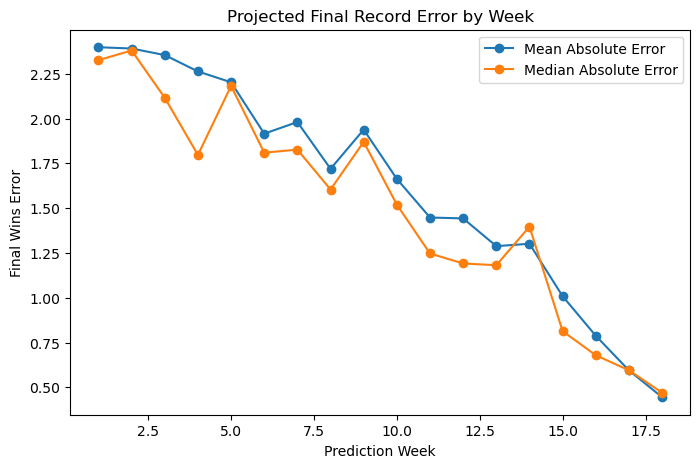

In [245]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    weekly_projection_error["prediction_week"],
    weekly_projection_error["mean_abs_error"],
    marker="o",
    label="Mean Absolute Error"
)
plt.plot(
    weekly_projection_error["prediction_week"],
    weekly_projection_error["median_abs_error"],
    marker="o",
    label="Median Absolute Error"
)
plt.xlabel("Prediction Week")
plt.ylabel("Final Wins Error")
plt.title("Projected Final Record Error by Week")
plt.legend()
plt.show()

In [246]:
week1_projections = record_projections_2025[
    record_projections_2025["games_played_entering"] == 0
].copy()

week1_projections = week1_projections.sort_values(
    "projected_final_win_equiv",
    ascending=False
)

week1_projections[[
    "team",
    "projected_final_win_equiv",
    "rounded_projected_record",
    "actual_wins",
    "actual_losses",
    "actual_ties",
    "actual_win_equiv",
    "abs_win_equiv_error"
]]

,team,projected_final_win_equiv,rounded_projected_record,actual_wins,actual_losses,actual_ties,actual_win_equiv,abs_win_equiv_error
29,Buffalo Bills,11.884600,12-5,12,5,0,12.0,0.115400
24,Detroit Lions,11.634039,12-5,9,8,0,9.0,2.634039
28,Baltimore Ravens,10.812840,11-6,8,9,0,8.0,2.812840
22,Denver Broncos,10.183664,10-7,14,3,0,14.0,3.816336
19,Tampa Bay Buccaneers,10.114133,10-7,8,9,0,8.0,2.114133
12,Indianapolis Colts,10.108685,10-7,8,9,0,8.0,2.108685
25,Green Bay Packers,9.801531,10-7,9,7,1,9.5,0.301531
21,Seattle Seahawks,9.705108,10-7,14,3,0,14.0,4.294892
1,Philadelphia Eagles,9.480163,9-8,11,6,0,11.0,1.519837
3,Los Angeles Chargers,9.188478,9-8,11,6,0,11.0,1.811522


In [247]:
week1_projections.to_csv("week1_2025_projected_records.csv", index=False)

In [248]:
last_projection_each_team = (
    record_projections_2025
    .sort_values(["team", "games_played_entering"])
    .groupby("team")
    .tail(1)
    .sort_values("projected_final_win_equiv", ascending=False)
)

last_projection_each_team[[
    "team",
    "prediction_week",
    "current_wins",
    "current_losses",
    "current_ties",
    "games_remaining",
    "projected_final_win_equiv",
    "rounded_projected_record",
    "actual_wins",
    "actual_losses",
    "actual_ties",
    "abs_win_equiv_error"
]]

,team,prediction_week,current_wins,current_losses,current_ties,games_remaining,projected_final_win_equiv,rounded_projected_record,actual_wins,actual_losses,actual_ties,abs_win_equiv_error
537,New England Patriots,18.0,13,3,0,1,13.743487,14-3,14,3,0,0.256513
534,Denver Broncos,18.0,13,3,0,1,13.599458,14-3,14,3,0,0.400542
515,Seattle Seahawks,18.0,13,3,0,1,13.507566,14-3,14,3,0,0.492434
526,Jacksonville Jaguars,18.0,12,4,0,1,12.791292,13-4,13,4,0,0.208708
514,San Francisco 49ers,18.0,12,4,0,1,12.492366,12-5,12,5,0,0.492366
538,Buffalo Bills,18.0,11,5,0,1,11.812728,12-5,12,5,0,0.187272
529,Los Angeles Rams,18.0,11,5,0,1,11.772514,12-5,12,5,0,0.227486
540,Philadelphia Eagles,18.0,11,5,0,1,11.643296,12-5,11,6,0,0.643296
522,Houston Texans,18.0,11,5,0,1,11.502658,12-5,12,5,0,0.497342
530,Chicago Bears,18.0,11,5,0,1,11.447660,11-6,11,6,0,0.447660


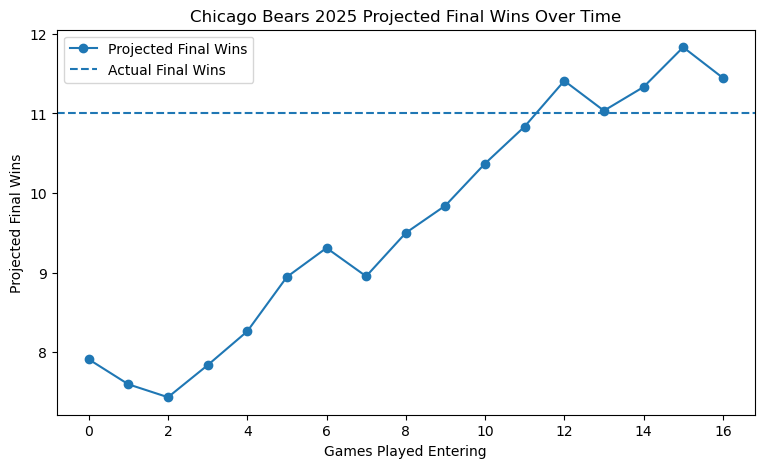

In [249]:
bears_projection = record_projections_2025[
    record_projections_2025["team"] == "Chicago Bears"
].copy()

plt.figure(figsize=(9, 5))
plt.plot(
    bears_projection["games_played_entering"],
    bears_projection["projected_final_win_equiv"],
    marker="o",
    label="Projected Final Wins"
)
plt.axhline(
    bears_projection["actual_win_equiv"].iloc[0],
    linestyle="--",
    label="Actual Final Wins"
)
plt.xlabel("Games Played Entering")
plt.ylabel("Projected Final Wins")
plt.title("Chicago Bears 2025 Projected Final Wins Over Time")
plt.legend()
plt.show()

In [250]:
record_projections_2025.to_csv("record_projections_2025.csv", index=False)

In [251]:
weekly_projection_error.to_csv("weekly_projection_error_2025.csv", index=False)

In [252]:
last_projection_each_team.to_csv("last_projection_each_team_2025.csv", index=False)

In [253]:
test_records = pd.read_csv("record_projections_2025.csv")
test_records.shape

(544, 26)

## Step 8 Record Projection Summary

Using the final tuned win-probability model, I converted individual game win probabilities into projected final team records. For each 2025 team-game row, I calculated the team's current record entering that game, summed its predicted win probabilities for the remaining schedule, and added those expected remaining wins to its current wins.

This produced rolling projected final records for all 32 teams throughout the 2025 regular season. Projection accuracy was evaluated using absolute error in final win-equivalent record, where ties count as half a win.